# System Setup

## Imports and Installs

### Installs

In [1]:
!pip install geopandas
!pip install geojson
!pip install overpass
!pip install alphashape

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.6/507.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.5/736.5 kB 29.6 MB/s eta 0:00:00


### Imports

In [2]:
import pandas as pd
import json
import geojson
#https://github.com/mvexel/overpass-api-python-wrapper/blob/main/README.md
import overpass
#https://pypi.org/project/osm2geojson/
import csv
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from shapely.geometry import Point, Polygon
import requests
import time
from google.colab import drive
import sys
import ast
from alphashape import alphashape
import geopandas as gpd
import os
from collections import defaultdict
import os.path
from tqdm import tqdm

In [3]:
import numpy as np
import pickle
import random
import json
from itertools import permutations
import time as time_module
import networkx as nx
from datetime import datetime
import geopy.distance
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra

## Parameters

In [4]:
state_name = "Ohio"
city_name = "Columbus"
mini = True

## Connecting to Drive

We first mount the drive. This step requires permission to be given. Running the cell should open a permission page to allow colab access to google drive.

In [5]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


Setting the file directory to the data folder. All files will be referenced to this working directory.

Folder structure:

```
📁Drive/
└─ 📁<personal_dir>/
   ├─ 📁<city_name_1> - RL Delivery Data/
   ├─ 📁<city_name_2> - RL Delivery Data/
   └─ 📁Raw GeoJsons/
```


## Assign Data directory path

In [6]:
personal_dir = "./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/"
data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"
output_dir = data_dir + "/UMST Graph/bundling"


In [7]:
try:
  os.mkdir(data_dir)
except:
  print(data_dir + " Already Exists")

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# See directory content
data = os.listdir(data_dir)
print("Files in directory : ", data)

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data Already Exists
Output directory: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/bundling
Files in directory :  ['Census Data', 'Images', 'Hotspot Data', 'Original Location Data', 'Processed Location Data', 'Q Tables', 'UMST Graph', 'gh_cache', 'Deliveries', 'avg_hotspot_data.json', 'experiment_results']


## Load Data

#### Loading city data

In [8]:
census_df = gpd.read_file(data_dir + "/Census Data/census_tract_data.geojson")
num_hotspots = len(census_df.index)
print(num_hotspots)

# === FILE PATHS ===
umst_path = data_dir + "/UMST Graph/graphs/umst_graph.graphml"
mst_path = data_dir + "/UMST Graph/graphs/mst_graph.graphml"
hotspot_path = data_dir + "/UMST Graph/graphs/gh_hotspot_graph.graphml"
census_path = data_dir + "/Census Data/census_tract_data.geojson"
hotspot_geojson_path = data_dir + "/Hotspot Data/hotspot_data.geojson"

# === 1. LOAD GRAPHS ===
print("\n[1] Loading graphs from files...")
umst_graph = nx.read_graphml(umst_path)
mst_graph = nx.read_graphml(mst_path)
hotspot_graph = nx.read_graphml(hotspot_path)

# Load census tract boundaries for visualization
try:
    census_gdf = gpd.read_file(census_path, crs='EPSG:4326')
    print(f"    ✓ Census tracts loaded: {len(census_gdf)} tracts")
except Exception as e:
    print(f"    ⚠ Warning: Could not load census data: {e}")
    print(f"    Continuing without census tract boundaries...")
    census_gdf = None

print(f"    ✓ Hotspot Graph: {hotspot_graph.number_of_nodes()} nodes, {hotspot_graph.number_of_edges()} edges")
print(f"    ✓ MST Graph: {mst_graph.number_of_nodes()} nodes, {mst_graph.number_of_edges()} edges")
print(f"    ✓ UMST Graph: {umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges")


# Get number of hotspots (nodes)
num_hotspots = umst_graph.number_of_nodes()
print(f"Number of hotspots: {num_hotspots}")

26

[1] Loading graphs from files...
    ✓ Census tracts loaded: 26 tracts
    ✓ Hotspot Graph: 26 nodes, 325 edges
    ✓ MST Graph: 26 nodes, 25 edges
    ✓ UMST Graph: 26 nodes, 47 edges
Number of hotspots: 26


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


In [9]:
def create_matrices_from_graph(graph: nx.Graph,
                               node_to_id: dict,
                               dist_attr: str = 'distance',
                               time_attr: str = 'time',
                               as_dataframe: bool = True,
                               calculate_shortest_paths: bool = True):
    n = len(node_to_id)

    dist_matrix = np.full((n, n), np.inf, dtype=float)
    time_matrix = np.full((n, n), np.inf, dtype=float)
    np.fill_diagonal(dist_matrix, 0)
    np.fill_diagonal(time_matrix, 0)

    edge_count = 0
    for u, v, data in graph.edges(data=True):
        i, j = node_to_id[u], node_to_id[v]
        dist = float(data.get(dist_attr, 0))
        time = float(data.get(time_attr, 0))

        time *= 60 # Convert minutes into seconds
        dist *= 1000 # Convert km into meters

        dist_matrix[i, j] = dist
        dist_matrix[j, i] = dist
        time_matrix[i, j] = time
        time_matrix[j, i] = time
        edge_count += 1

    print(f"Graph: {n} nodes, {edge_count} edges")

    if calculate_shortest_paths:
        print("Calculating shortest paths...")
        dist_matrix = _compute_shortest_paths(dist_matrix)
        time_matrix = _compute_shortest_paths(time_matrix)

        unreachable = np.sum(dist_matrix == np.inf) - n
        total_pairs = n * (n - 1)
        print(f"Reachable: {total_pairs - unreachable}/{total_pairs} pairs")
        if unreachable > 0:
            print(f"WARNING: {unreachable} pairs unreachable")

    if as_dataframe:
        node_labels = list(node_to_id.keys())
        dist_matrix = pd.DataFrame(dist_matrix, index=node_labels, columns=node_labels)
        time_matrix = pd.DataFrame(time_matrix, index=node_labels, columns=node_labels)

    return dist_matrix, time_matrix


def _compute_shortest_paths(matrix):
    matrix_sparse = matrix.copy()
    matrix_sparse[matrix_sparse == np.inf] = 0
    sparse_matrix = csr_matrix(matrix_sparse)
    shortest_paths = dijkstra(csgraph=sparse_matrix, directed=False, return_predecessors=False)
    return shortest_paths

In [10]:
nodes = sorted(umst_graph.nodes())
index_to_tract = {idx: node for idx, node in enumerate(nodes)}  # id → node
tract_to_index = {node: idx for idx, node in enumerate(nodes)}  # node → id

# Get numpy arrays with integer indices
full_dist_matrix, full_time_matrix = create_matrices_from_graph(
    graph=umst_graph,
    node_to_id=tract_to_index,  # Use tract_to_index (node → id)
    calculate_shortest_paths=True,
    as_dataframe=False  # ← Important! Get numpy arrays, not DataFrames
)

print("Distance matrix shape:", full_dist_matrix.shape)
print("Time matrix shape:", full_time_matrix.shape)
print("\nSample distance matrix (integer indexed):")
print(full_dist_matrix[:10, :10])
print("\nSample time matrix (integer indexed):")
print(full_time_matrix[:10, :10])

# Now you can access by integer index
print(f"\nDistance from node 0 to node 5: {full_dist_matrix[0, 5]:.3f} m")
print(f"Time from node 0 to node 5: {full_time_matrix[0, 5]:.0f} seconds")

Graph: 26 nodes, 47 edges
Calculating shortest paths...
Reachable: 676/650 pairs
Distance matrix shape: (26, 26)
Time matrix shape: (26, 26)

Sample distance matrix (integer indexed):
[[   0. 1016. 1829.  967. 1842. 4296. 5003. 2928. 2861. 3622.]
 [1016.    0. 1711. 1929. 2804. 5258. 5965. 3890. 3823. 3504.]
 [1829. 1711.    0. 1920. 1464. 3918. 4625. 2550. 2483. 1793.]
 [ 967. 1929. 1920.    0.  875. 3329. 4036. 1961. 1894. 3106.]
 [1842. 2804. 1464.  875.    0. 2454. 3161. 1086. 1019. 2231.]
 [4296. 5258. 3918. 3329. 2454.    0.  707. 2843. 3473. 4685.]
 [5003. 5965. 4625. 4036. 3161.  707.    0. 2415. 3154. 4366.]
 [2928. 3890. 2550. 1961. 1086. 2843. 2415.    0.  739. 1951.]
 [2861. 3823. 2483. 1894. 1019. 3473. 3154.  739.    0. 1212.]
 [3622. 3504. 1793. 3106. 2231. 4685. 4366. 1951. 1212.    0.]]

Sample time matrix (integer indexed):
[[  0. 207. 299. 156. 273. 601. 758. 429. 377. 545.]
 [207.   0. 234. 258. 375. 703. 860. 531. 479. 569.]
 [299. 234.   0. 289. 261. 589. 746. 417

In [11]:
# print("Graph edges with attributes:")
# for u, v, data in umst_graph.edges(data=True):
#     print(f"{u} -- {v} | distance={data.get('distance')} | time={data.get('time')}")


#### Creating Full/"Estimate" Distance and Time matrices
**Note:** The Estimate matrices will only be created if they do not already exist.

In [12]:
# if "estimate_distance_adjacency_matrix.npy" not in os.listdir(data_dir + "/Hotspot Data") or "estimate_time_adjacency_matrix.npy" not in os.listdir(data_dir + "/Hotspot Data"):
#   # Import hotspots and order according to tract_to_index
#   hotspot_df = gpd.read_file(data_dir + "/Hotspot Data/hotspot_data.geojson")
#   hotspot_df['index_order'] = hotspot_df['GEOID'].map(tract_to_index)
#   hotspot_df = hotspot_df.sort_values(by='index_order').reset_index(drop=True)
#   hotspot_df = hotspot_df.drop(columns=['index_order'])


#   # Turn hotspot dataframe into a matrix of coordinates getting the distance between them
#   coords = hotspot_df['geometry'].apply(lambda geom: (geom.x, geom.y)).tolist()
#   estimate_dist_matrix = np.zeros((len(coords), len(coords)))

#   # Calculate pairwise geodesic distances
#   for i, coord1 in enumerate(coords):
#     for j, coord2 in enumerate(coords):
#       estimate_dist_matrix[i, j] = geodesic(coord1, coord2).meters if i != j else 0.0

#   # Add the average distance longer that actual roads take to the crow-flies distances
#   dist_diff_matrix = full_dist_matrix - estimate_dist_matrix
#   dist_diff_matrix = dist_diff_matrix[dist_diff_matrix < 100000000]
#   avg_increase = dist_diff_matrix.mean()
#   estimate_dist_matrix = estimate_dist_matrix + avg_increase

#   # Get the speed of the distances from the distance/time matrices
#   speed_matrix = full_dist_matrix / full_time_matrix
#   np.nan_to_num(speed_matrix, 0)  # Set nan values to 0

#   # Exclude values where speed is 1, as the vast majority (if not all) indicate edges that dont exist
#   valid_speeds_mask = (speed_matrix != 1) & ~np.isnan(speed_matrix)

#   # Mask speed matrix
#   valid_speeds = speed_matrix[valid_speeds_mask]
#   average_speed = np.mean(valid_speeds) # Get the mean of the matrix, this gives the average speed for each distance travelled

#   estimate_time_matrix = estimate_dist_matrix / average_speed  # Use this and the full distance matrix to create the full time matrix

#   np.save(data_dir + f"/Hotspot Data/estimate_distance_adjacency_matrix.npy", estimate_dist_matrix)
#   np.save(data_dir + f"/Hotspot Data/estimate_time_adjacency_matrix.npy", estimate_time_matrix)

# estimate_dist_matrix = np.load(data_dir + f"/Hotspot Data/estimate_distance_adjacency_matrix.npy")
# estimate_time_matrix = np.load(data_dir + f"/Hotspot Data/estimate_time_adjacency_matrix.npy")

Below the full distance/time matrices are created and updated as necessary

In [13]:
# if "full_distance_adjacency_matrix.npy" not in os.listdir(data_dir + "/Hotspot Data") or "full_time_adjacency_matrix.npy" not in os.listdir(data_dir + "/Hotspot Data"):
#   print("Creating new")

#   np.save(data_dir + f"/Hotspot Data/full_distance_adjacency_matrix.npy", full_dist_matrix)
#   np.save(data_dir + f"/Hotspot Data/full_time_adjacency_matrix.npy", full_time_matrix)

# else:
#   print("Already exist")
#   full_dist_matrix = np.load(data_dir + f"/Hotspot Data/full_distance_adjacency_matrix.npy")
#   full_time_matrix = np.load(data_dir + f"/Hotspot Data/full_time_adjacency_matrix.npy")

#   # Copy distance/time_matrix data onto full, and save it again.
#   for i in range(len(census_df.index)):
#     for j in range(len(census_df.index)):
#       if full_dist_matrix[i, j] == sys.maxsize and full_dist_matrix[i, j] != sys.maxsize:
#         full_dist_matrix[i, j] = full_dist_matrix[i, j]
#         full_time_matrix[i, j] = full_time_matrix[i, j]

#   np.save(data_dir + f"/Hotspot Data/full_distance_adjacency_matrix.npy", full_dist_matrix)
#   np.save(data_dir + f"/Hotspot Data/full_time_adjacency_matrix.npy", full_time_matrix)


# Simulation Materials

#### Global Variables and Functions

In [14]:
INTERVALS = [900, 1200, 1500, 1800, 2700, 3600, 5400, 7200, 10800, 14400, 36000]

In [15]:
# Changed the directory
deliveries_dir = data_dir + f"/Deliveries"
try:
  os.mkdir(deliveries_dir)
except:
  print(deliveries_dir + " Already Exists")

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Deliveries Already Exists


### Deliveries

#### Delivery Class

In [16]:
# ============================================================
# 1. DELIVERY CLASS - Simplified
# ============================================================

class Delivery:
    """
    Represents a single delivery request.
    ONLY tracks its own state - no partner tracking.
    """
    id_counter = 0

    def __init__(self, start_node, end_node, start_time, time_tolerance_factor,
                 shortest_path=None):
        # Identity
        self.id = Delivery.id_counter
        Delivery.id_counter += 1

        # Route (immutable)
        self.start_node = start_node
        self.end_node = end_node
        self.shortest_path = shortest_path if shortest_path else [start_node, end_node]

        # Time constraints
        self.start_time = start_time
        self.TIME_TOLERANCE_FACTOR = time_tolerance_factor
        self.time_limit = None  # Set after initialization

        # Current state (mutable)
        self.current_node = start_node
        self.path_index = 0
        self.in_transition = False
        self.time_till_next_node = 0
        self.wait_time_remaining = 0

        # Completion tracking
        self.completed = False
        self.successful = False
        self.end_time = None

        # Statistics
        self.distance_traveled = 0
        self.actual_path = [start_node]
        self.num_vehicle_changes = 0

        # Bundle reference (managed by Bundle class)
        self.current_bundle_id = None  # Just an ID reference, not the full object

    def get_next_node(self):
        """Get next node in planned path."""
        if self.path_index < len(self.shortest_path) - 1:
            return self.shortest_path[self.path_index + 1]
        return None

    def move_to_next_node(self, distance, travel_time):
        """Start transition to next node."""
        self.in_transition = True
        self.time_till_next_node = travel_time
        self.distance_traveled += distance

    def arrive_at_node(self, node):
        """Complete arrival at node."""
        self.in_transition = False
        self.current_node = node
        self.actual_path.append(node)
        self.path_index += 1

        # CRITICAL: Check if reached destination
        if self.current_node == self.end_node:
            self.completed = True
            # Note: successful status set later in finalize_results based on time_limit

    def reset(self):
        """Reset to initial state."""
        self.current_node = self.start_node
        self.path_index = 0
        self.in_transition = False
        self.time_till_next_node = 0
        self.wait_time_remaining = 0
        self.completed = False
        self.successful = False
        self.end_time = None
        self.distance_traveled = 0
        self.actual_path = [self.start_node]
        self.num_vehicle_changes = 0
        self.current_bundle_id = None

    def __repr__(self):
        status = "✅" if self.completed else ("🚗" if self.in_transition else "⏳")
        bundle = f"[B{self.current_bundle_id}]" if self.current_bundle_id else ""
        return f"D{self.id}:{self.start_node}→{self.end_node}|{status}{bundle}@N{self.current_node}"


#### Vehicle Class

In [17]:
# ============================================================
# 2. VEHICLE CLASS - Simple tracking
# ============================================================

class Vehicle:
    """
    Represents a physical vehicle.
    Can be reused for multiple trips (BUNDLING MODE ONLY).
    """
    id_counter = 0

    def __init__(self, start_node, allow_reuse=True):
        self.id = Vehicle.id_counter
        Vehicle.id_counter += 1

        self.current_node = start_node
        self.allow_reuse = allow_reuse  # Only true for bundling mode

        # Cumulative stats (never reset)
        self.total_distance = 0
        self.total_trips = 0
        self.all_deliveries_carried = set()

        # Current trip (reset on reuse)
        self.current_trip_distance = 0
        self.current_route = [start_node]
        self.is_in_use = False

        # Reuse management
        self.available_at_time = 0  # Time when vehicle becomes available
        self.cooldown_period = 600  # 10 minutes cooldown before reuse

    def move_to(self, next_node, distance):
        """Move vehicle to next node."""
        self.current_node = next_node
        self.total_distance += distance
        self.current_trip_distance += distance
        self.current_route.append(next_node)

    def start_new_trip(self, start_node, current_time):
        """Prepare for new trip (reuse)."""
        if not self.allow_reuse:
            raise ValueError("Vehicle reuse not allowed in baseline mode")

        self.current_node = start_node
        self.current_trip_distance = 0
        self.current_route = [start_node]
        self.total_trips += 1
        self.is_in_use = True
        self.available_at_time = 0  # Reset availability

    def release(self, current_time):
        """Mark as available for reuse after cooldown."""
        self.is_in_use = False
        if self.allow_reuse:
            self.available_at_time = current_time + self.cooldown_period

    def can_reuse(self, current_time):
        """Check if vehicle can be reused."""
        return self.allow_reuse and not self.is_in_use and current_time >= self.available_at_time

    def __repr__(self):
        return f"V{self.id}@N{self.current_node}|{self.total_distance/1000:.1f}km"


In [18]:
# ============================================================
# 3. BUNDLE CLASS - Central bundling manager
# ============================================================

class Bundle:
    """
    Manages a group of deliveries sharing a vehicle.
    This is the SINGLE SOURCE OF TRUTH for bundling.
    """
    id_counter = 0

    def __init__(self, delivery_ids, vehicle, current_node, next_node, step):
        self.id = Bundle.id_counter
        Bundle.id_counter += 1

        self.delivery_ids = set(delivery_ids)  # Set of delivery IDs
        self.vehicle = vehicle
        self.current_node = current_node
        self.next_node = next_node
        self.created_at_step = step

        self.is_active = True
        self.dissolved_at_step = None
        self.dissolution_reason = None

    def add_delivery(self, delivery_id):
        """Add delivery to bundle."""
        self.delivery_ids.add(delivery_id)

    def remove_delivery(self, delivery_id):
        """Remove delivery from bundle."""
        self.delivery_ids.discard(delivery_id)

    def dissolve(self, step, reason):
        """Dissolve this bundle."""
        self.is_active = False
        self.dissolved_at_step = step
        self.dissolution_reason = reason

    def size(self):
        """Current bundle size."""
        return len(self.delivery_ids)

    def __repr__(self):
        status = "🟢" if self.is_active else "🔴"
        return f"{status}Bundle{self.id}:[{','.join(f'D{d}' for d in sorted(self.delivery_ids))}]@V{self.vehicle.id}"


#### DeliveryList Class

In [19]:
# ============================================================
# 4. DELIVERYLIST CLASS - Keep mostly as is
# ============================================================

class DeliveryList:
    """Manages collection of deliveries with shortest path calculation."""

    def __init__(self, distance_based, load, time_tolerance_factor,
                 hours=1, peaks=[0.25, 0.75], sigma=10, num_hotspots=50,
                 time_matrix=None, distance_matrix=None):
        self.distance_based = distance_based
        self.load = load
        self.hours = hours
        self.peaks = peaks
        self.sigma = sigma
        self.time_tolerance_factor = time_tolerance_factor
        self.num_hotspots = num_hotspots
        self.time_matrix = time_matrix
        self.distance_matrix = distance_matrix

        print("📊 Generating temporal distribution...")
        self.distribution, self.loads = self.generate_distribution()

        print("📦 Generating deliveries with shortest paths...")
        self.deliveries = self.generate_deliveries()

        # Calculate time limits after generation
        self.calculate_time_limits()

        print(f"✅ Generated {len(self.deliveries)} deliveries")

    def generate_distribution(self):
        """Generate temporal distribution of deliveries."""
        mu_list = [peak * 60 * self.hours for peak in self.peaks]
        x = np.linspace(0, 60 * self.hours, 60 * self.hours)

        y_combined = np.zeros_like(x)
        for mu in mu_list:
            y_combined += (1 / (self.sigma * np.sqrt(2 * np.pi))) * \
                         np.exp(-0.5 * ((x - mu) / self.sigma) ** 2)

        loads = [int((self.load * (self.sigma * np.sqrt(2 * np.pi))) * y)
                for y in y_combined]

        return y_combined, loads

    def calculate_shortest_path(self, start, end):
        """Calculate shortest path using Dijkstra's algorithm."""
        if start == end:
            return [start]

        if self.time_matrix is None:
            return [start, end]

        dist = np.full(self.num_hotspots, np.inf)
        dist[start] = 0
        prev = np.full(self.num_hotspots, -1, dtype=int)
        unvisited = set(range(self.num_hotspots))

        while unvisited:
            current = min(unvisited, key=lambda x: dist[x])

            if dist[current] == np.inf or current == end:
                break

            unvisited.remove(current)

            for neighbor in range(self.num_hotspots):
                if neighbor in unvisited:
                    edge_time = self.time_matrix[current, neighbor]
                    if edge_time != sys.maxsize and edge_time > 0:
                        alt = dist[current] + edge_time
                        if alt < dist[neighbor]:
                            dist[neighbor] = alt
                            prev[neighbor] = current

        if dist[end] == np.inf:
            return [start, end]

        path = []
        current = end
        while current != -1:
            path.append(current)
            current = prev[current]

        path.reverse()
        return path

    def calculate_time_limits(self):
        """Calculate time limits for all deliveries."""
        INTERVALS = [300, 600, 900, 1200, 1800, 2400, 3000, 3600]

        for delivery in self.deliveries:
            try:
                path_time = self.time_matrix[delivery.start_node][delivery.end_node]
                required_time = path_time * delivery.TIME_TOLERANCE_FACTOR

                for interval in INTERVALS:
                    if required_time <= interval:
                        delivery.time_limit = interval
                        break
                else:
                    delivery.time_limit = float('inf')
            except:
                delivery.time_limit = float('inf')

    def generate_deliveries(self):
        """Generate delivery requests with shortest paths."""
        valid_nodes = list(range(self.num_hotspots))
        deliveries = []

        with tqdm(total=sum(self.loads), desc="Creating deliveries") as pbar:
            for j in range(60 * self.hours):
                for _ in range(self.loads[j]):
                    while True:
                        start = random.choice(valid_nodes)
                        end = random.choice(valid_nodes)
                        if start != end:
                            break

                    time = random.randint(j * 60, (j + 1) * 60)
                    shortest_path = self.calculate_shortest_path(start, end)

                    delivery = Delivery(
                        start, end, time,
                        time_tolerance_factor=self.time_tolerance_factor,
                        shortest_path=shortest_path
                    )
                    deliveries.append(delivery)
                    pbar.update(1)

        return deliveries

    def reset_deliveries(self):
        """Reset all deliveries."""
        for d in self.deliveries:
            d.reset()


### Environment

In [20]:
# ============================================================
# 5. SIMULATION CLASS - Orchestrates everything
# ============================================================

class Simulation:
    """
    Main simulation engine.
    Manages deliveries, bundles, and vehicles.
    """

    def __init__(self, deliverylist, distance_matrix, time_matrix, num_hotspots,
                 wait_time=30, max_bundle_size=4, vehicle_change_time=15,
                 vehicle_cooldown=600, debug=False):

        self.deliverylist = deliverylist
        self.distance_matrix = distance_matrix
        self.time_matrix = time_matrix
        self.num_hotspots = num_hotspots
        self.wait_time = wait_time
        self.max_bundle_size = max_bundle_size
        self.vehicle_change_time = vehicle_change_time
        self.vehicle_cooldown = vehicle_cooldown  # Time before vehicle can be reused
        self.debug = debug

        # Time
        self.clock = 0
        self.time_step = 10
        self.step_count = 0

        # Deliveries
        self.all_deliveries = {d.id: d for d in deliverylist.deliveries}
        self.active_deliveries = set()  # Delivery IDs
        self.dormant_deliveries = set(d.id for d in deliverylist.deliveries)

        # Bundles (SINGLE SOURCE OF TRUTH)
        self.bundles = {}  # bundle_id -> Bundle
        self.active_bundles = set()  # Active bundle IDs

        # Vehicles
        self.vehicles = {}  # vehicle_id -> Vehicle
        self.available_vehicles = []  # Pool of available vehicles
        self.use_bundling = True  # Set during run()

        # Statistics
        self.bundles_created = 0
        self.bundles_dissolved = 0
        self.bundles_merged = 0
        self.peak_active_vehicles = 0
        self.active_vehicles_history = []

    def run(self, grace_time, use_bundling=True):
        """Run simulation."""
        self.use_bundling = use_bundling  # Store for vehicle creation
        max_time = self.deliverylist.hours * 60 * 60 + grace_time

        mode = "BUNDLING" if use_bundling else "BASELINE"
        print(f"\n{'='*80}")
        print(f"🚀 {mode} SIMULATION")
        print(f"{'='*80}")
        print(f"⏱️  Max time: {max_time}s ({max_time/3600:.2f}hr)")
        print(f"⏳ Wait time: {self.wait_time}s")
        print(f"🚗 Max bundle: {self.max_bundle_size} deliveries")
        if use_bundling:
            print(f"🔄 Vehicle cooldown: {self.vehicle_cooldown}s")
        print(f"📦 Total deliveries: {len(self.all_deliveries)}")
        print(f"{'='*80}\n")

        while self.clock < max_time and (self.active_deliveries or self.dormant_deliveries):
            self.step(use_bundling)

            if self.clock % 600 == 0 and self.debug:
                self.print_status()

        self.finalize_results()
        self.print_summary()

    def step(self, use_bundling):
        """Execute one simulation step."""
        self.step_count += 1

        # Phase 1: Activate new deliveries
        self.activate_deliveries()

        # Phase 2: Move all deliveries in transit
        self.move_deliveries()

        # Phase 3: Handle bundling logic
        if use_bundling:
            self.handle_unbundling()  # Dissolve diverging bundles
            self.handle_bundling()    # Create/merge bundles
        else:
            self.handle_baseline()    # Individual vehicles

        # Phase 4: Track metrics
        self.track_metrics()

        # Advance time
        self.clock += self.time_step

    def activate_deliveries(self):
        """Move deliveries from dormant to active."""
        to_activate = [d_id for d_id in self.dormant_deliveries
                       if self.all_deliveries[d_id].start_time <= self.clock]

        for d_id in to_activate:
            self.active_deliveries.add(d_id)
            self.dormant_deliveries.remove(d_id)

            if self.debug and len(to_activate) <= 3:
                print(f"  📦 NEW: {self.all_deliveries[d_id]}")

        if self.debug and len(to_activate) > 3:
            print(f"  📦 {len(to_activate)} new deliveries")

    def move_deliveries(self):
        """Move all deliveries in transit."""
        completed = []

        for d_id in list(self.active_deliveries):
            delivery = self.all_deliveries[d_id]

            # TRANSIT: Delivery is moving between nodes
            if delivery.in_transition:
                delivery.time_till_next_node -= self.time_step

                if delivery.time_till_next_node <= 0:
                    # ARRIVAL at next node
                    next_node = delivery.get_next_node()
                    if next_node is None:
                        # Something wrong - shouldn't be in transition if no next node
                        if self.debug:
                            print(f"  ⚠️ WARNING: D{d_id} in transition but no next node")
                        delivery.in_transition = False
                        continue

                    delivery.arrive_at_node(next_node)

                    # Check if completed (reached destination)
                    if delivery.completed:
                        delivery.end_time = self.clock
                        completed.append(d_id)

                        if self.debug:
                            print(f"  ✅ D{d_id} COMPLETED at N{delivery.current_node} (time={self.clock}s)")

                        # Remove from bundle if bundled
                        if delivery.current_bundle_id:
                            self.remove_from_bundle(d_id, "completed")
                    else:
                        # Not at destination yet - reset wait time for potential rebundling
                        if not delivery.current_bundle_id:
                            delivery.wait_time_remaining = self.wait_time
                continue

            # WAITING: Decrement wait time for deliveries not in transit
            if not delivery.completed and delivery.wait_time_remaining > 0:
                delivery.wait_time_remaining -= self.time_step

        # Remove completed deliveries
        for d_id in completed:
            self.active_deliveries.remove(d_id)

    def handle_unbundling(self):
        """
        Check and dissolve bundles with diverging paths.
        IMPROVED: Keeps partial bundles alive if 2+ deliveries still share path.
        """
        for bundle_id in list(self.active_bundles):
            bundle = self.bundles[bundle_id]

            # Group deliveries by next destination
            next_destinations = defaultdict(list)
            for d_id in list(bundle.delivery_ids):
                delivery = self.all_deliveries[d_id]
                if not delivery.in_transition and not delivery.completed:
                    next_node = delivery.get_next_node()
                    next_destinations[next_node].append(d_id)

            # If all going to same place, continue
            if len(next_destinations) <= 1:
                continue

            # Paths diverge - need to split bundle
            if self.debug:
                print(f"    🔀 SPLIT: Bundle{bundle_id} diverging to {len(next_destinations)} destinations")

            # Dissolve original bundle
            self.dissolve_bundle(bundle_id, "path_divergence")

            # Create NEW bundles for each group of 2+
            for next_node, delivery_ids in next_destinations.items():
                if next_node is None:
                    # Deliveries completed - skip
                    continue

                if len(delivery_ids) >= 2:
                    # Still enough to bundle
                    current_node = self.all_deliveries[delivery_ids[0]].current_node
                    self.create_bundle(delivery_ids, current_node, next_node)

                    if self.debug:
                        print(f"      ↳ Sub-bundle created: [{','.join(f'D{d}' for d in delivery_ids)}] → N{next_node}")
                else:
                    # Single delivery - let it wait for new partners
                    d_id = delivery_ids[0]
                    delivery = self.all_deliveries[d_id]
                    delivery.wait_time_remaining = self.wait_time

                    if self.debug:
                        print(f"      ↳ D{d_id} now solo, waiting for partners")

    def handle_bundling(self):
        """Create and merge bundles at each node."""
        # Group deliveries by (current_node, next_node)
        node_groups = defaultdict(lambda: defaultdict(list))

        for d_id in self.active_deliveries:
            delivery = self.all_deliveries[d_id]

            if delivery.in_transition or delivery.completed:
                continue

            next_node = delivery.get_next_node()
            if next_node is not None:
                node_groups[delivery.current_node][next_node].append(d_id)
            elif next_node is None and delivery.current_node != delivery.end_node:
                # Delivery thinks it has no next node but hasn't reached destination
                # This shouldn't happen but let's mark it as stuck
                if self.debug:
                    print(f"  ⚠️ WARNING: D{d_id} has no next node but not at destination!")
                    print(f"     Current: N{delivery.current_node}, Target: N{delivery.end_node}")
                    print(f"     Path: {delivery.shortest_path}, Index: {delivery.path_index}")

        # Process each (current_node, next_node) group
        for current_node, dest_groups in node_groups.items():
            for next_node, delivery_ids in dest_groups.items():

                # Skip if max_bundle_size is 1 (no bundling)
                if self.max_bundle_size == 1:
                    # All deliveries move solo
                    for d_id in delivery_ids:
                        delivery = self.all_deliveries[d_id]
                        if delivery.wait_time_remaining <= 0:
                            self.initiate_delivery_movement(d_id, current_node, next_node)
                    continue

                if len(delivery_ids) < 2:
                    # Lone delivery - set wait time
                    for d_id in delivery_ids:
                        delivery = self.all_deliveries[d_id]
                        if delivery.wait_time_remaining == 0 and not delivery.current_bundle_id:
                            delivery.wait_time_remaining = self.wait_time
                        elif delivery.wait_time_remaining <= 0:
                            # Waited long enough - move solo
                            self.initiate_delivery_movement(d_id, current_node, next_node)
                    continue

                # Separate bundled vs unbundled
                bundled = defaultdict(list)  # bundle_id -> delivery_ids
                unbundled = []

                for d_id in delivery_ids:
                    delivery = self.all_deliveries[d_id]
                    if delivery.current_bundle_id:
                        bundled[delivery.current_bundle_id].append(d_id)
                    elif delivery.wait_time_remaining <= 0:
                        unbundled.append(d_id)

                # STRATEGY 1: Merge existing bundles
                if len(bundled) > 1:
                    all_bundled = []
                    for bundle_deliveries in bundled.values():
                        all_bundled.extend(bundle_deliveries)

                    if len(all_bundled) <= self.max_bundle_size:
                        # Dissolve old bundles and create merged bundle
                        for bundle_id in bundled.keys():
                            self.dissolve_bundle(bundle_id, "merge")

                        self.create_bundle(all_bundled, current_node, next_node)
                        self.bundles_merged += 1
                        continue

                # STRATEGY 2: Add unbundled to existing bundles
                for bundle_id, bundle_deliveries in bundled.items():
                    bundle = self.bundles[bundle_id]
                    slots_available = self.max_bundle_size - bundle.size()

                    if slots_available > 0 and unbundled:
                        to_add = unbundled[:slots_available]
                        unbundled = unbundled[slots_available:]

                        for d_id in to_add:
                            self.add_to_bundle(bundle_id, d_id)

                # STRATEGY 3: Create new bundles from unbundled
                while len(unbundled) >= 2:
                    group = unbundled[:self.max_bundle_size]
                    unbundled = unbundled[self.max_bundle_size:]

                    self.create_bundle(group, current_node, next_node)

                # STRATEGY 4: Remaining singles - initiate movement immediately
                for d_id in unbundled:
                    delivery = self.all_deliveries[d_id]
                    if delivery.wait_time_remaining <= 0:
                        # Waited long enough - move solo
                        self.initiate_delivery_movement(d_id, current_node, next_node)
                    else:
                        # Still waiting for partners
                        if delivery.wait_time_remaining == 0:
                            delivery.wait_time_remaining = self.wait_time

        # CRITICAL: Move all bundled deliveries that are ready
        self.move_bundled_deliveries()

    def handle_baseline(self):
        """
        Baseline: Each delivery gets individual vehicle (NO REUSE).
        Each delivery = one dedicated vehicle for entire journey.
        """
        for d_id in self.active_deliveries:
            delivery = self.all_deliveries[d_id]

            if delivery.in_transition or delivery.completed:
                continue

            next_node = delivery.get_next_node()
            if next_node is None:
                continue

            # Ready to move immediately (no waiting in baseline)
            # Get dedicated vehicle (create if first time for this delivery)
            if not hasattr(delivery, '_dedicated_vehicle_id'):
                # Create NEW vehicle for this delivery (no reuse in baseline)
                vehicle = Vehicle(delivery.current_node, allow_reuse=False)
                self.vehicles[vehicle.id] = vehicle
                delivery._dedicated_vehicle_id = vehicle.id
                vehicle.is_in_use = True

                if self.debug and self.clock < 100:
                    print(f"  🚗 NEW VEHICLE V{vehicle.id} for D{d_id}")
            else:
                vehicle = self.vehicles[delivery._dedicated_vehicle_id]

            # Move delivery and vehicle together
            distance = self.distance_matrix[delivery.current_node, next_node]
            travel_time = self.time_matrix[delivery.current_node, next_node]

            delivery.move_to_next_node(distance, travel_time)
            vehicle.move_to(next_node, distance)
            vehicle.all_deliveries_carried.add(d_id)

    def create_bundle(self, delivery_ids, current_node, next_node):
        """Create new bundle."""
        if len(delivery_ids) < 2:
            return

        # Get vehicle (reuse if available and cooled down)
        vehicle = self.get_vehicle(current_node)

        # Create bundle
        bundle = Bundle(delivery_ids, vehicle, current_node, next_node, self.step_count)
        self.bundles[bundle.id] = bundle
        self.active_bundles.add(bundle.id)

        # Update deliveries
        for d_id in delivery_ids:
            delivery = self.all_deliveries[d_id]
            delivery.current_bundle_id = bundle.id
            delivery.wait_time_remaining = 0
            delivery.num_vehicle_changes += 1

            # Clear any solo vehicle reference
            if hasattr(delivery, '_current_solo_vehicle_id'):
                delivery._current_solo_vehicle_id = None

        # Start movement for all deliveries in bundle
        distance = self.distance_matrix[current_node, next_node]
        travel_time = self.time_matrix[current_node, next_node]

        for d_id in delivery_ids:
            delivery = self.all_deliveries[d_id]
            delivery.move_to_next_node(distance, travel_time)

        # Move vehicle ONCE (shared by all) - this is the key!
        vehicle.move_to(next_node, distance)
        for d_id in delivery_ids:
            vehicle.all_deliveries_carried.add(d_id)

        self.bundles_created += 1

        if self.debug:
            print(f"    🔗 BUNDLE{bundle.id} created @ N{current_node}: "
                  f"[{','.join(f'D{d}' for d in sorted(delivery_ids))}] → N{next_node} (V{vehicle.id})")

    def dissolve_bundle(self, bundle_id, reason):
        """Dissolve bundle and release vehicle with cooldown."""
        if bundle_id not in self.bundles:
            return

        bundle = self.bundles[bundle_id]
        bundle.dissolve(self.step_count, reason)

        # Clear delivery references
        for d_id in list(bundle.delivery_ids):
            if d_id in self.all_deliveries:
                self.all_deliveries[d_id].current_bundle_id = None

        # Release vehicle with cooldown
        bundle.vehicle.release(self.clock)
        if bundle.vehicle.allow_reuse:
            self.available_vehicles.append(bundle.vehicle)

        self.active_bundles.discard(bundle_id)
        self.bundles_dissolved += 1

        if self.debug:
            print(f"    🔓 BUNDLE{bundle_id} dissolved ({reason})")

    def add_to_bundle(self, bundle_id, delivery_id):
        """Add delivery to existing bundle."""
        bundle = self.bundles[bundle_id]
        bundle.add_delivery(delivery_id)

        delivery = self.all_deliveries[delivery_id]
        delivery.current_bundle_id = bundle_id
        delivery.wait_time_remaining = 0
        delivery.num_vehicle_changes += 1

    def remove_from_bundle(self, delivery_id, reason):
        """Remove delivery from its bundle."""
        delivery = self.all_deliveries[delivery_id]
        if not delivery.current_bundle_id:
            return

        bundle_id = delivery.current_bundle_id
        bundle = self.bundles[bundle_id]

        bundle.remove_delivery(delivery_id)
        delivery.current_bundle_id = None

        # If bundle empty, dissolve
        if bundle.size() == 0:
            self.dissolve_bundle(bundle_id, reason)

    def initiate_delivery_movement(self, delivery_id, current_node, next_node):
        """Start a solo delivery moving to next node."""
        delivery = self.all_deliveries[delivery_id]

        # In bundling mode with max_bundle_size=1, treat like baseline
        # Use one dedicated vehicle per delivery for its entire journey
        if self.max_bundle_size == 1:
            if not hasattr(delivery, '_dedicated_vehicle_id'):
                vehicle = Vehicle(current_node, allow_reuse=False)
                self.vehicles[vehicle.id] = vehicle
                delivery._dedicated_vehicle_id = vehicle.id
                vehicle.is_in_use = True
            else:
                vehicle = self.vehicles[delivery._dedicated_vehicle_id]
        else:
            # In normal bundling mode, get vehicle for this segment
            # Check if delivery completed its previous segment and needs new vehicle
            vehicle = self.get_vehicle(current_node)
            delivery.num_vehicle_changes += 1

        # Calculate movement
        distance = self.distance_matrix[current_node, next_node]
        travel_time = self.time_matrix[current_node, next_node]

        # Start movement
        delivery.move_to_next_node(distance, travel_time)
        vehicle.move_to(next_node, distance)
        vehicle.all_deliveries_carried.add(delivery_id)

        if self.debug and self.step_count % 60 == 0:  # Log occasionally
            print(f"    🚶 SOLO: D{delivery_id} N{current_node}→N{next_node} (V{vehicle.id})")

    def move_bundled_deliveries(self):
        """Initiate movement for all bundled deliveries that are waiting at nodes."""
        for bundle_id in list(self.active_bundles):
            bundle = self.bundles[bundle_id]

            # Check if bundle members are all at the same node and not moving
            if not bundle.is_active:
                continue

            members_at_node = []
            for d_id in bundle.delivery_ids:
                if d_id not in self.all_deliveries:
                    continue
                delivery = self.all_deliveries[d_id]
                if not delivery.in_transition and not delivery.completed:
                    members_at_node.append(d_id)

            # If all members are waiting at a node, start them moving
            if len(members_at_node) >= 2:
                first_delivery = self.all_deliveries[members_at_node[0]]
                current_node = first_delivery.current_node
                next_node = first_delivery.get_next_node()

                if next_node is not None:
                    # Calculate movement
                    distance = self.distance_matrix[current_node, next_node]
                    travel_time = self.time_matrix[current_node, next_node]

                    # Move all members
                    for d_id in members_at_node:
                        delivery = self.all_deliveries[d_id]
                        if not delivery.in_transition:  # Safety check
                            delivery.move_to_next_node(distance, travel_time)

                    # Move vehicle ONCE - DO NOT MOVE MULTIPLE TIMES!
                    # Only move if vehicle hasn't already moved this step
                    if bundle.vehicle.current_node == current_node:
                        bundle.vehicle.move_to(next_node, distance)

    def get_vehicle(self, start_node):
        """
        Get vehicle (reuse if available and cooled down, or create new).
        Only reuses in BUNDLING mode.
        """
        # Try to reuse available vehicle (only in bundling mode)
        if self.use_bundling and self.available_vehicles:
            # Check vehicles that have cooled down
            for vehicle in list(self.available_vehicles):
                if vehicle.can_reuse(self.clock):
                    self.available_vehicles.remove(vehicle)
                    vehicle.start_new_trip(start_node, self.clock)

                    if self.debug and self.clock < 200:
                        print(f"  ♻️  REUSING V{vehicle.id} (cooled down, {vehicle.total_trips} trips)")

                    return vehicle

        # Create new vehicle
        vehicle = Vehicle(start_node, allow_reuse=self.use_bundling)
        vehicle.cooldown_period = self.vehicle_cooldown
        self.vehicles[vehicle.id] = vehicle
        vehicle.is_in_use = True
        return vehicle

    def track_metrics(self):
        """Track metrics for this step."""
        active_vehicles = set()
        for bundle_id in self.active_bundles:
            bundle = self.bundles[bundle_id]
            active_vehicles.add(bundle.vehicle.id)

        self.active_vehicles_history.append(len(active_vehicles))
        self.peak_active_vehicles = max(self.peak_active_vehicles, len(active_vehicles))

    def finalize_results(self):
        """Calculate final metrics."""
        for delivery in self.all_deliveries.values():
            if delivery.end_time is None:
                continue

            actual_time = (delivery.end_time - delivery.start_time) + \
                         (delivery.num_vehicle_changes * self.vehicle_change_time)

            if actual_time <= delivery.time_limit:
                delivery.successful = True

    def print_status(self):
        """Print current status."""
        completed = sum(1 for d in self.all_deliveries.values() if d.completed)
        bundled = sum(1 for d in self.all_deliveries.values()
                     if d.current_bundle_id is not None)

        print(f"\n{'='*80}")
        print(f"⏰ {self.clock}s ({self.clock/60:.1f}min)")
        print(f"📦 Active:{len(self.active_deliveries)} Dormant:{len(self.dormant_deliveries)} Done:{completed}")
        print(f"🔗 Bundles: {len(self.active_bundles)} active, {bundled} deliveries bundled")
        print(f"🚗 Vehicles: {len(self.vehicles)} total, {len(self.available_vehicles)} available")
        print(f"{'='*80}")

    def print_summary(self):
        """Print final summary."""
        results = self.get_results()

        print(f"\n{'='*80}")
        print(f"🏁 SIMULATION COMPLETE - {self.clock}s ({self.clock/3600:.2f}hr)")
        print(f"{'='*80}")
        print(f"📦 Total Deliveries: {len(self.all_deliveries)}")
        print(f"✅ Completed: {results['completed']} ({results['completion_rate']:.1%})")
        print(f"🎯 Successful (on-time): {results['successful']} ({results['success_rate']:.1%})")
        print(f"⏰ Late: {results['completed'] - results['successful']} "
              f"({(results['completed'] - results['successful'])/len(self.all_deliveries):.1%})")

        if self.use_bundling:
            print(f"\n🔗 Bundling Events:")
            print(f"   • Created: {self.bundles_created}")
            print(f"   • Merged: {self.bundles_merged}")
            print(f"   • Dissolved: {self.bundles_dissolved}")
            print(f"   • Participation: {results['bundling_participation']:.1%}")

        print(f"\n🚗 Vehicle Metrics:")
        print(f"   • Total vehicles: {len(self.vehicles)}")
        print(f"   • Vehicle reuse: {'Enabled' if self.use_bundling else 'Disabled (Baseline)'}")
        if self.use_bundling:
            reused = sum(1 for v in self.vehicles.values() if v.total_trips > 1)
            print(f"   • Reused vehicles: {reused} ({reused/len(self.vehicles):.1%})")
            avg_trips = sum(v.total_trips for v in self.vehicles.values()) / len(self.vehicles)
            print(f"   • Avg trips per vehicle: {avg_trips:.2f}")

        print(f"\n📏 Distance:")
        print(f"   • Vehicle distance: {results['vehicle_distance']/1000:.1f}km")
        print(f"   • Delivery distance: {results['delivery_distance']/1000:.1f}km")

        if results['delivery_distance'] > 0:
            savings = (results['delivery_distance'] - results['vehicle_distance']) / results['delivery_distance']
            print(f"   • Distance saved: {(results['delivery_distance'] - results['vehicle_distance'])/1000:.1f}km ({savings:.1%})")

        print(f"\n⏱️  Time:")
        print(f"   • Avg delivery time: {results['avg_time']:.1f}s ({results['avg_time']/60:.1f}min)")

        print(f"{'='*80}\n")

    def get_results(self):
        """Get simulation results."""
        completed = [d for d in self.all_deliveries.values() if d.completed]
        successful = [d for d in self.all_deliveries.values() if d.successful]

        # Calculate distances
        delivery_distance = sum(d.distance_traveled for d in completed)
        vehicle_distance = sum(v.total_distance for v in self.vehicles.values())

        # Calculate times
        times = []
        for d in completed:
            actual_time = (d.end_time - d.start_time) + \
                         (d.num_vehicle_changes * self.vehicle_change_time)
            times.append(actual_time)

        # Bundle size distribution
        bundle_sizes = defaultdict(int)
        for bundle in self.bundles.values():
            bundle_sizes[bundle.size()] += 1

        return {
            'completed': len(completed),
            'successful': len(successful),
            'completion_rate': len(completed) / len(self.all_deliveries),
            'success_rate': len(successful) / len(self.all_deliveries),
            'vehicle_distance': vehicle_distance,
            'delivery_distance': delivery_distance,
            'distance_saved': delivery_distance - vehicle_distance,
            'avg_time': np.mean(times) if times else 0,
            'total_vehicles': len(self.vehicles),
            'peak_active_vehicles': self.peak_active_vehicles,
            'avg_active_vehicles': np.mean(self.active_vehicles_history) if self.active_vehicles_history else 0,
            'bundles_created': self.bundles_created,
            'bundles_merged': self.bundles_merged,
            'bundles_dissolved': self.bundles_dissolved,
            'bundle_sizes': dict(bundle_sizes),
            'times': times,
            'bundling_participation': sum(1 for d in self.all_deliveries.values()
                                         if any(b.delivery_ids.__contains__(d.id)
                                               for b in self.bundles.values())) / len(self.all_deliveries)
        }

    def reset(self):
        """Reset simulation."""
        self.deliverylist.reset_deliveries()
        Delivery.id_counter = 0
        Vehicle.id_counter = 0
        Bundle.id_counter = 0
        self.__init__(
            self.deliverylist,
            self.distance_matrix,
            self.time_matrix,
            self.num_hotspots,
            self.wait_time,
            self.max_bundle_size,
            self.vehicle_change_time,
            self.debug
        )

In [21]:
# ============================================================
# 6. VISUALIZATION FUNCTIONS
# ============================================================

def plot_delivery_analysis(sim, num_paths=15):
    """Visualize delivery paths and bundling analysis."""
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

    # ========== PLOT 1: Delivery Timeline ==========
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    deliveries = [d for d in list(sim.all_deliveries.values())[:num_paths] if d.end_time is not None]

    for i, delivery in enumerate(deliveries):
        color = 'green' if delivery.successful else 'red'
        ax1.plot([delivery.start_time, delivery.end_time], [i, i],
                color=color, linewidth=4, alpha=0.7)

        ax1.scatter(delivery.start_time, i, color='blue', s=120, marker='o',
                   zorder=5, edgecolors='black', linewidths=1.5)
        ax1.scatter(delivery.end_time, i, color=color, s=120, marker='s',
                   zorder=5, edgecolors='black', linewidths=1.5)

        path_str = "→".join(map(str, delivery.actual_path[:6]))
        if len(delivery.actual_path) > 6:
            path_str += "..."
        ax1.text(delivery.start_time - 50, i, f"D{delivery.id}:{path_str}",
                fontsize=9, va='center', ha='right', fontweight='bold')

    ax1.set_xlabel('Time (seconds)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Delivery', fontsize=13, fontweight='bold')
    ax1.set_title('📅 Delivery Timeline', fontsize=15, fontweight='bold', pad=20)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_yticks(range(len(deliveries)))
    ax1.set_yticklabels([f"D{d.id}" for d in deliveries])

    legend_elements = [
        mpatches.Patch(color='blue', label='🔵 Start'),
        mpatches.Patch(color='green', label='🟢 Success'),
        mpatches.Patch(color='red', label='🔴 Failed')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)

    # ========== PLOT 2: Bundle Size Distribution ==========
    ax2 = fig.add_subplot(gs[0, 2])
    results = sim.get_results()
    bundle_sizes = results['bundle_sizes']

    if bundle_sizes:
        sizes = sorted(bundle_sizes.keys())
        counts = [bundle_sizes[s] for s in sizes]

        bars = ax2.bar(sizes, counts, color='coral', edgecolor='black',
                      alpha=0.8, linewidth=1.5)

        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax2.set_xlabel('Bundle Size', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax2.set_title('📦 Bundle Sizes', fontsize=13, fontweight='bold')
        ax2.set_xticks(sizes)
        ax2.grid(True, alpha=0.3, axis='y')
    else:
        ax2.text(0.5, 0.5, 'No Bundles', ha='center', va='center',
                fontsize=12, transform=ax2.transAxes, fontweight='bold')

    # ========== PLOT 3: Bundling Events ==========
    ax3 = fig.add_subplot(gs[1, 2])
    event_types = ['Created', 'Merged', 'Dissolved']
    event_counts = [sim.bundles_created, sim.bundles_merged, sim.bundles_dissolved]
    colors = ['mediumseagreen', 'skyblue', 'lightcoral']

    bars = ax3.bar(event_types, event_counts, color=colors, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax3.set_title('🔗 Bundle Events', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # ========== PLOT 4: Distance Comparison ==========
    ax4 = fig.add_subplot(gs[2, 0])

    vehicle_dist = results['vehicle_distance'] / 1000
    delivery_dist = results['delivery_distance'] / 1000
    saved = results['distance_saved'] / 1000

    categories = ['Vehicle\nDistance', 'Delivery\nDistance', 'Saved']
    values = [vehicle_dist, delivery_dist, saved]
    colors_bar = ['skyblue', 'lightcoral', 'mediumseagreen']

    bars = ax4.bar(categories, values, color=colors_bar, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}km', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax4.set_ylabel('Distance (km)', fontsize=11, fontweight='bold')
    ax4.set_title('📏 Distance Metrics', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')

    # ========== PLOT 5: Success Rate ==========
    ax5 = fig.add_subplot(gs[2, 1])

    success_rate = results['success_rate'] * 100
    fail_rate = 100 - success_rate

    wedges, texts, autotexts = ax5.pie([success_rate, fail_rate],
                                        labels=['Success', 'Failed'],
                                        colors=['mediumseagreen', 'lightcoral'],
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})

    ax5.set_title('🎯 Success Rate', fontsize=13, fontweight='bold')

    # ========== PLOT 6: Vehicle Usage ==========
    ax6 = fig.add_subplot(gs[2, 2])

    metrics = ['Unique\nVehicles', 'Bundling\nRate (%)']
    values = [results['total_vehicles'], results['bundling_participation'] * 100]
    colors_bar = ['mediumpurple', 'orange']

    bars = ax6.bar(metrics, values, color=colors_bar, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for i, bar in enumerate(bars):
        height = bar.get_height()
        label = f'{int(height)}' if i == 0 else f'{height:.1f}%'
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax6.set_ylabel('Count / Percentage', fontsize=11, fontweight='bold')
    ax6.set_title('🚗 Vehicle Efficiency', fontsize=13, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')

    plt.suptitle('📊 Opportunistic Bundling Analysis Dashboard',
                fontsize=18, fontweight='bold', y=0.995)

    plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
    print("\n✅ Dashboard saved as 'bundling_dashboard.png'")
    plt.show()


def plot_comparison(bundling_results, baseline_results):
    """Compare bundling vs baseline."""
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('📊 Bundling vs Baseline Comparison', fontsize=18, fontweight='bold')

    # Success Rate
    ax = axes[0, 0]
    bundling_sr = bundling_results['success_rate'] * 100
    baseline_sr = baseline_results['success_rate'] * 100

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_sr, baseline_sr],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('🎯 Success Rate', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(bundling_sr, baseline_sr) * 1.2)

    # Vehicle Distance
    ax = axes[0, 1]
    bundling_vdist = bundling_results['vehicle_distance'] / 1000
    baseline_vdist = baseline_results['vehicle_distance'] / 1000

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_vdist, baseline_vdist],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}km', ha='center', va='bottom', fontsize=11, fontweight='bold')

    reduction = (baseline_vdist - bundling_vdist) / baseline_vdist * 100 if baseline_vdist > 0 else 0
    ax.set_ylabel('Vehicle Distance (km)', fontsize=12, fontweight='bold')
    ax.set_title(f'📏 Vehicle Distance\n({reduction:+.1f}% reduction)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Time
    ax = axes[0, 2]
    bundling_time = bundling_results['avg_time']
    baseline_time = baseline_results['avg_time']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_time, baseline_time],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.0f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Avg Time (s)', fontsize=12, fontweight='bold')
    ax.set_title('⏱️ Average Time', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Vehicles Used
    ax = axes[1, 0]
    bundling_veh = bundling_results['total_vehicles']
    baseline_veh = baseline_results['total_vehicles']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_veh, baseline_veh],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    reduction_veh = (baseline_veh - bundling_veh) / baseline_veh * 100 if baseline_veh > 0 else 0
    ax.set_ylabel('Vehicle Count', fontsize=12, fontweight='bold')
    ax.set_title(f'🚗 Vehicles Used\n({reduction_veh:+.1f}% reduction)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Distance Saved
    ax = axes[1, 1]
    distance_saved = bundling_results['distance_saved'] / 1000

    bars = ax.bar(['Distance Saved'], [distance_saved],
                  color='mediumseagreen', edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}km', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Distance (km)', fontsize=12, fontweight='bold')
    ax.set_title('💾 Distance Saved by Bundling', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Summary
    ax = axes[1, 2]
    ax.axis('off')

    improvements = [
        f"Success Rate: {(bundling_sr - baseline_sr):+.1f}%",
        f"Vehicles: {reduction_veh:+.1f}%",
        f"Vehicle Dist: {reduction:+.1f}%",
        f"Distance Saved: {distance_saved:.1f}km",
        f"",
        f"Bundles Created: {bundling_results['bundles_created']}",
        f"Bundles Merged: {bundling_results['bundles_merged']}",
        f"Bundling Rate: {bundling_results['bundling_participation']*100:.1f}%",
    ]

    summary_text = "📈 IMPROVEMENT\n" + "="*25 + "\n\n" + "\n".join(improvements)

    ax.text(0.5, 0.5, summary_text, ha='center', va='center',
           fontsize=12, fontweight='bold', family='monospace',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, pad=1))

    plt.tight_layout()
    plt.savefig('bundling_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Comparison saved as 'bundling_comparison.png'")
    plt.show()



In [22]:
# ============================================================
# 7. MAIN RUNNER FUNCTIONS
# ============================================================

def run_bundling_simulation(deliverylist, distance_matrix, time_matrix,
                            num_hotspots, grace_time, wait_time=30,
                            max_bundle_size=4, vehicle_change_time=15,
                            vehicle_cooldown=600, debug=True):
    """Run simulation with bundling."""
    sim = Simulation(
        deliverylist=deliverylist,
        distance_matrix=distance_matrix,
        time_matrix=time_matrix,
        num_hotspots=num_hotspots,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        vehicle_change_time=vehicle_change_time,
        vehicle_cooldown=vehicle_cooldown,
        debug=debug
    )

    sim.run(grace_time=grace_time, use_bundling=True)
    results = sim.get_results()

    return results, sim


def run_baseline_simulation(deliverylist, distance_matrix, time_matrix,
                            num_hotspots, grace_time, wait_time=30,
                            max_bundle_size=4, vehicle_change_time=15,
                            vehicle_cooldown=600):
    """Run baseline (no bundling) simulation."""
    sim = Simulation(
        deliverylist=deliverylist,
        distance_matrix=distance_matrix,
        time_matrix=time_matrix,
        num_hotspots=num_hotspots,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        vehicle_change_time=vehicle_change_time,
        vehicle_cooldown=vehicle_cooldown,
        debug=False
    )

    sim.run(grace_time=grace_time, use_bundling=False)
    results = sim.get_results()

    return results, sim


def compare_systems(deliverylist, distance_matrix, time_matrix, num_hotspots,
                   grace_time, wait_time=30, max_bundle_size=4, vehicle_change_time=15,
                   vehicle_cooldown=600):
    """Full comparison of bundling vs baseline."""

    # Run bundling simulation
    print("\n" + "🟢"*40)
    print("RUNNING BUNDLING SIMULATION")
    print("🟢"*40)
    bundling_results, bundling_sim = run_bundling_simulation(
        deliverylist, distance_matrix, time_matrix, num_hotspots,
        grace_time, wait_time, max_bundle_size, vehicle_change_time,
        vehicle_cooldown, debug=True
    )

    # Reset for baseline
    deliverylist.reset_deliveries()
    Delivery.id_counter = 0
    Vehicle.id_counter = 0
    Bundle.id_counter = 0

    # Run baseline simulation
    print("\n" + "🔵"*40)
    print("RUNNING BASELINE SIMULATION (NO BUNDLING)")
    print("🔵"*40)
    baseline_results, baseline_sim = run_baseline_simulation(
        deliverylist, distance_matrix, time_matrix, num_hotspots,
        grace_time, wait_time, max_bundle_size, vehicle_change_time,
        vehicle_cooldown
    )

    # Print comparison
    print("\n" + "="*80)
    print("🔄 BUNDLING VS BASELINE COMPARISON")
    print("="*80)
    print(f"{'Metric':<35} {'Bundling':<20} {'Baseline':<20} {'Improvement':<15}")
    print("-"*90)

    metrics = [
        ('Completion Rate (%)', bundling_results['completion_rate']*100, baseline_results['completion_rate']*100),
        ('Success Rate (%)', bundling_results['success_rate']*100, baseline_results['success_rate']*100),
        ('Vehicles Used', bundling_results['total_vehicles'], baseline_results['total_vehicles']),
        ('Vehicle Distance (km)', bundling_results['vehicle_distance']/1000, baseline_results['vehicle_distance']/1000),
        ('Delivery Distance (km)', bundling_results['delivery_distance']/1000, baseline_results['delivery_distance']/1000),
        ('Avg Time (s)', bundling_results['avg_time'], baseline_results['avg_time']),
    ]

    for name, bund_val, base_val in metrics:
        if base_val > 0:
            if 'Rate' in name:
                delta = bund_val - base_val
                imp = f"{delta:+.2f}pp"  # percentage points
            else:
                delta = ((base_val - bund_val) / base_val) * 100
                imp = f"{delta:+.1f}%"
            print(f"{name:<35} {bund_val:<20.2f} {base_val:<20.2f} {imp:<15}")
        else:
            print(f"{name:<35} {bund_val:<20.2f} {base_val:<20.2f} {'N/A':<15}")

    print(f"\n💾 Distance Saved by Bundling: {bundling_results['distance_saved']/1000:.1f}km")
    print(f"🔗 Bundling Events: {bundling_results['bundles_created']} created, "
          f"{bundling_results['bundles_merged']} merged, {bundling_results['bundles_dissolved']} dissolved")
    print(f"📊 Bundling Participation: {bundling_results['bundling_participation']:.1%}")

    # Vehicle reuse stats
    bundling_reused = sum(1 for v in bundling_sim.vehicles.values() if v.total_trips > 1)
    print(f"♻️  Vehicle Reuse: {bundling_reused}/{len(bundling_sim.vehicles)} vehicles reused in bundling")
    print(f"🚫 Baseline: No reuse (each delivery = dedicated vehicle)")

    print("="*90)

    # Generate visualizations
    plot_delivery_analysis(bundling_sim, num_paths=20)
    plot_comparison(bundling_results, baseline_results)

    return bundling_results, baseline_results



## Final Function Call

📊 Generating temporal distribution...
📦 Generating deliveries with shortest paths...


Creating deliveries: 100%|██████████| 9234/9234 [00:01<00:00, 6571.16it/s]


Streaming output truncated to the last 5000 lines.
  ✅ D6438 COMPLETED at N11 (time=2820s)
  ✅ D6453 COMPLETED at N14 (time=2820s)
  ✅ D6883 COMPLETED at N22 (time=2820s)
    🔓 BUNDLE1636 dissolved (completed)
  ✅ D7053 COMPLETED at N7 (time=2820s)
  ✅ D7059 COMPLETED at N18 (time=2820s)
    🔓 BUNDLE1663 dissolved (completed)
    🔗 BUNDLE1793 created @ N4: [D5741,D7411] → N15 (V2353)
    🔗 BUNDLE1794 created @ N15: [D5715,D7474] → N21 (V4370)
    🔗 BUNDLE1795 created @ N16: [D6552,D7550] → N12 (V4372)
    🔗 BUNDLE1796 created @ N3: [D6179,D7358] → N23 (V4375)
    🔗 BUNDLE1797 created @ N24: [D5925,D7617] → N6 (V4377)
    🔗 BUNDLE1798 created @ N24: [D7263,D7574] → N8 (V4378)
    🔗 BUNDLE1799 created @ N19: [D7095,D7388] → N2 (V4382)
    🔗 BUNDLE1800 created @ N25: [D2785,D7369] → N11 (V4383)
    🔗 BUNDLE1801 created @ N25: [D4578,D7345] → N18 (V4384)
    🔗 BUNDLE1802 created @ N25: [D6170,D7535] → N24 (V4385)
    🔗 BUNDLE1803 created @ N8: [D4918,D7485] → N17 (V4388)
    🔗 BUNDLE1804 c

/tmp/ipython-input-2658370985.py:152: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-2658370985.py:152: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-2658370985.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-2658370985.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-2658370985.py:152: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-2658370985.py:152: UserWarning: Glyph 12


✅ Dashboard saved as 'bundling_dashboard.png'


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dis

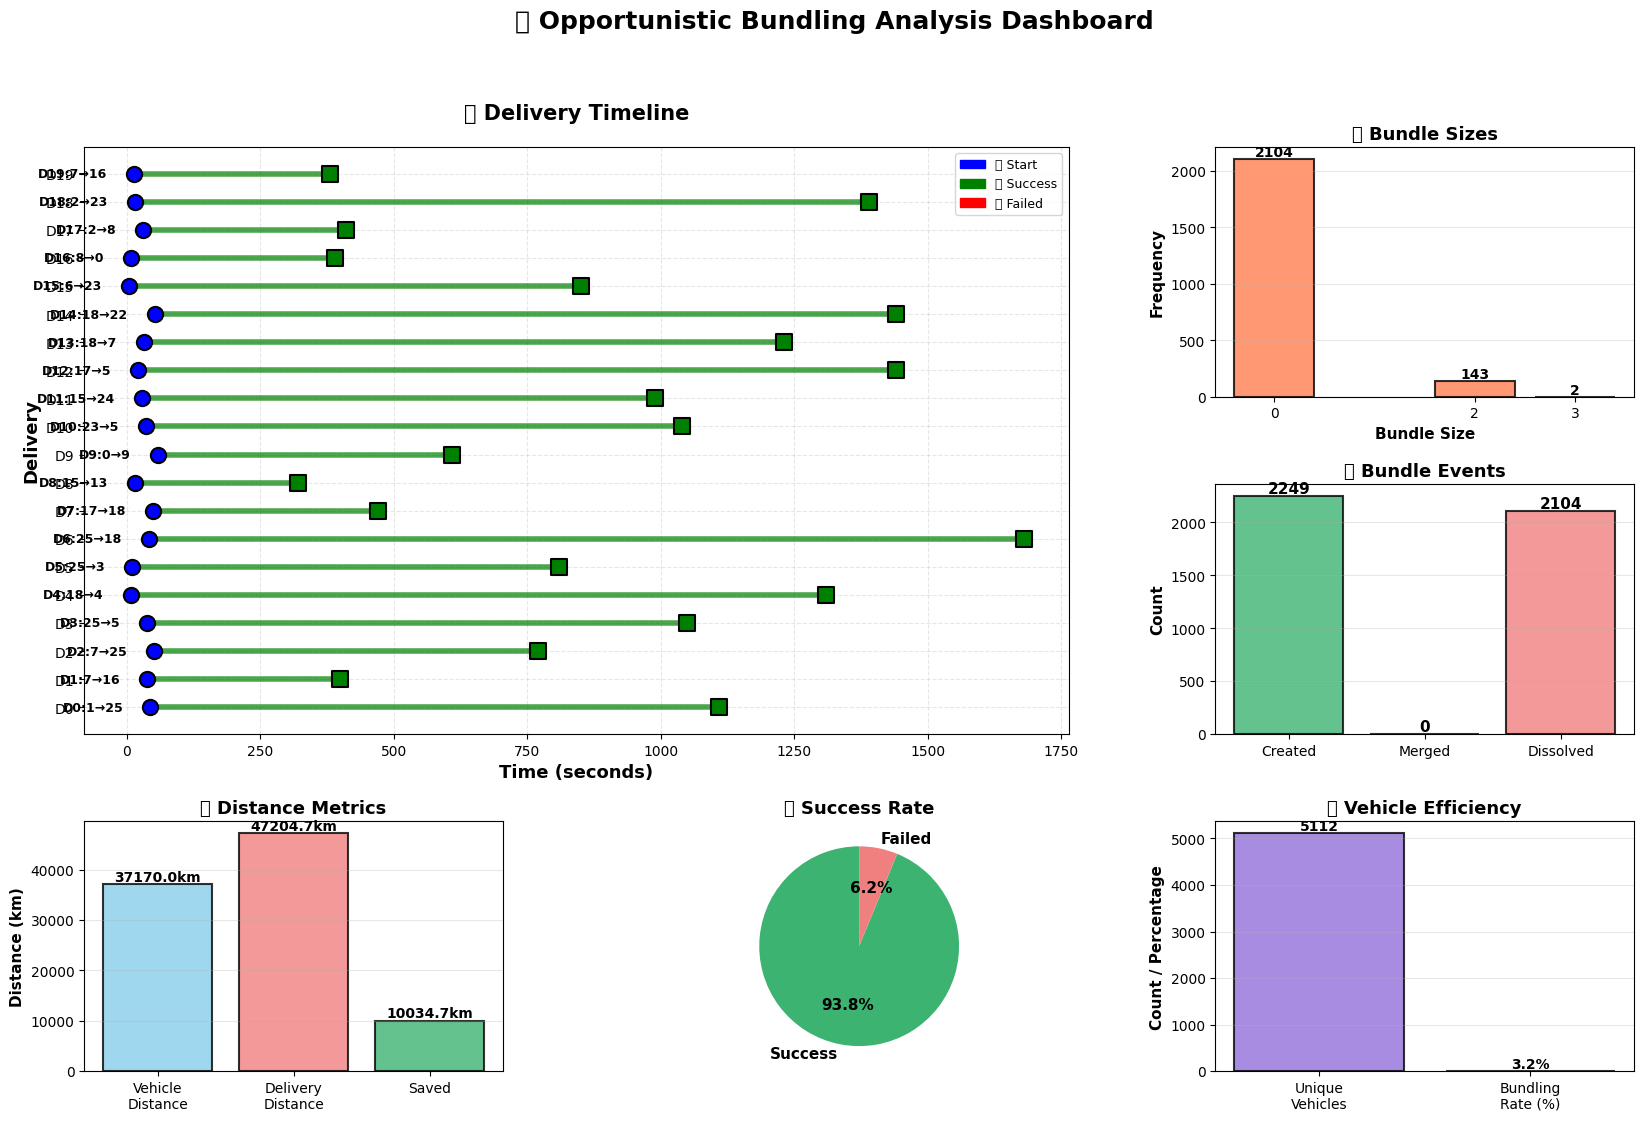

/tmp/ipython-input-2658370985.py:272: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2658370985.py:272: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2658370985.py:272: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2658370985.py:272: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2658370985.py:272: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2658370985.py:272: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-2658370985.py:272: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-265837098

✅ Comparison saved as 'bundling_comparison.png'


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


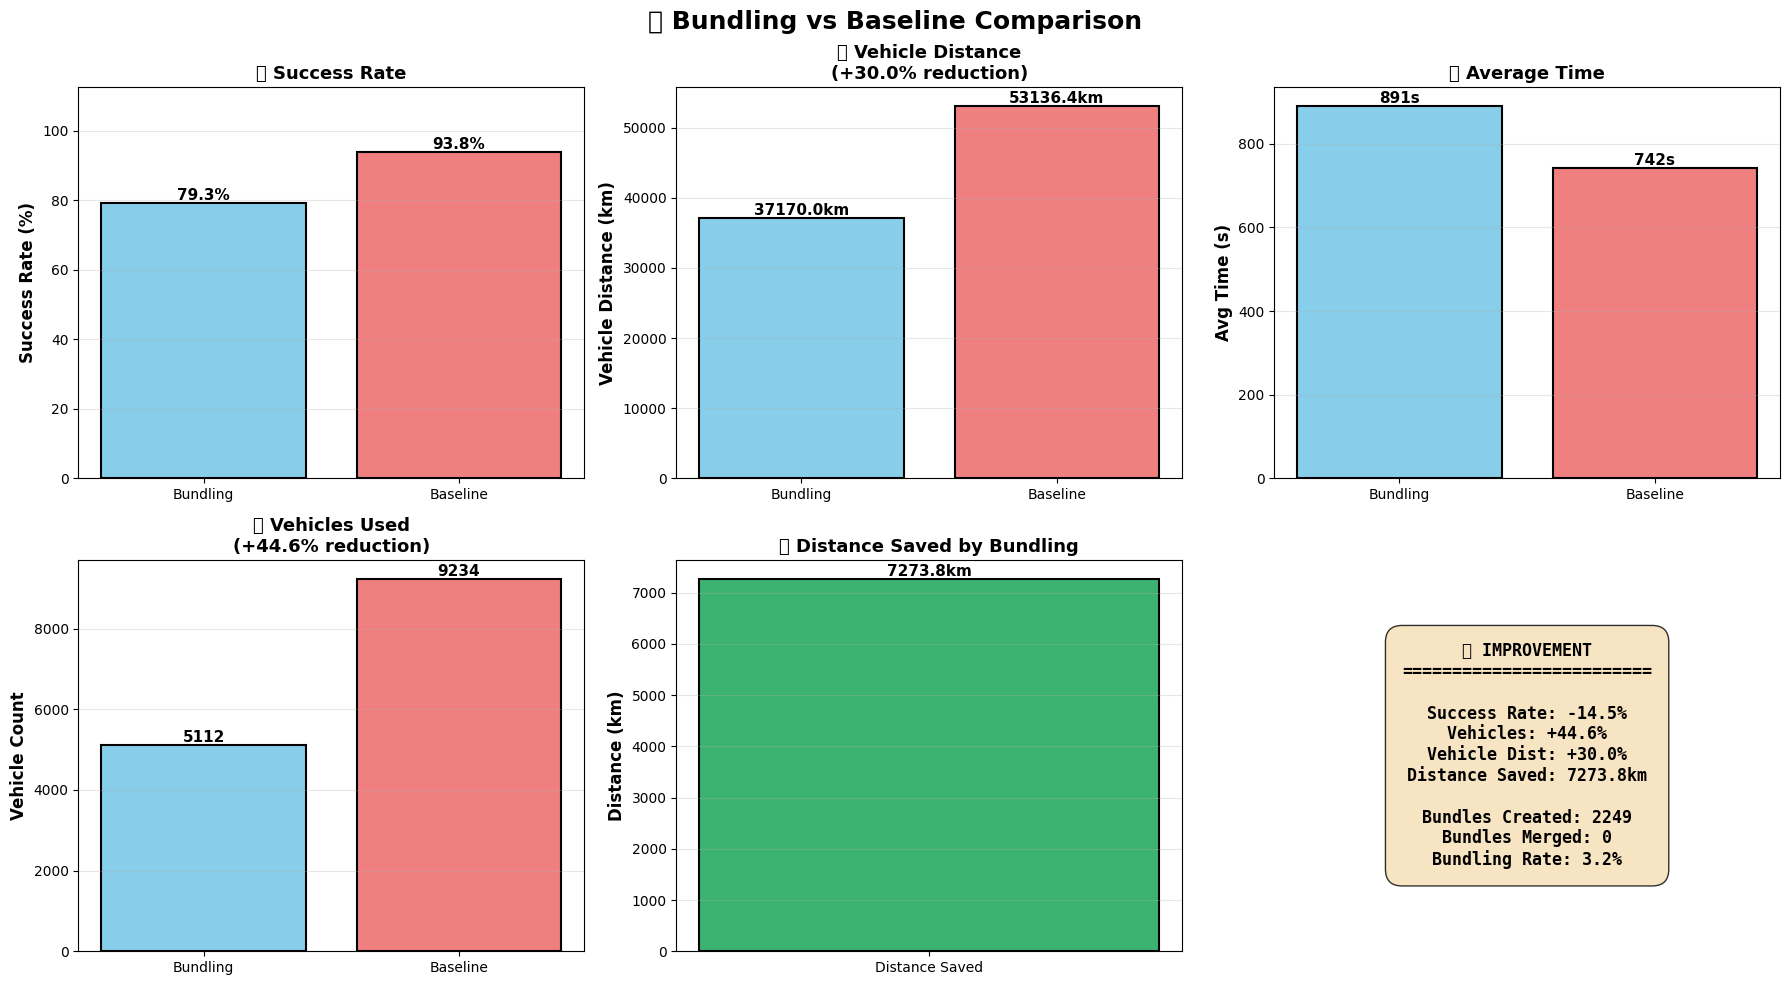


🚀 BUNDLING SIMULATION
⏱️  Max time: 4200s (1.17hr)
⏳ Wait time: 30s
🚗 Max bundle: 4 deliveries
🔄 Vehicle cooldown: 600s
📦 Total deliveries: 9234

  📦 10 new deliveries
  📦 10 new deliveries
  📦 9 new deliveries
  📦 14 new deliveries
  📦 9 new deliveries
  📦 12 new deliveries
  📦 12 new deliveries
  📦 11 new deliveries
  📦 18 new deliveries
  📦 16 new deliveries
  📦 7 new deliveries
  📦 13 new deliveries
  📦 24 new deliveries
  📦 11 new deliveries
  📦 19 new deliveries
  📦 15 new deliveries
  📦 10 new deliveries
  📦 7 new deliveries
  📦 18 new deliveries
  📦 20 new deliveries
  📦 19 new deliveries
  📦 17 new deliveries
  📦 10 new deliveries
  📦 12 new deliveries
  📦 15 new deliveries
  📦 26 new deliveries
  📦 19 new deliveries
  📦 17 new deliveries
  📦 17 new deliveries
  📦 17 new deliveries
  📦 24 new deliveries
  📦 28 new deliveries
  📦 23 new deliveries
  📦 5 new deliveries
  📦 20 new deliveries
  📦 23 new deliveries
  📦 24 new deliveries
  📦 23 new deliveries
  📦 27 new deliveries


ZeroDivisionError: division by zero

In [26]:
# ============================================================
# 8. EXAMPLE USAGE
# ============================================================
# Create delivery list (you need your distance/time matrices)
deliverylist = DeliveryList(
    distance_based="further",
    load=100,
    time_tolerance_factor=1.5,
    hours=1,
    peaks=[0.25, 0.75],
    sigma=10,
    num_hotspots=num_hotspots,
    time_matrix=full_time_matrix,
    distance_matrix=full_dist_matrix
)

# Run comparison
bundling_results, baseline_results = compare_systems(
    deliverylist=deliverylist,
    distance_matrix=full_dist_matrix,
    time_matrix=full_time_matrix,
    num_hotspots=num_hotspots,
    grace_time=600,           # Extra time after all deliveries arrive
    wait_time=30,             # Max wait for bundle partners (seconds)
    max_bundle_size=4,        # Max deliveries per vehicle
    vehicle_change_time=15,   # Penalty per vehicle change (seconds)
    vehicle_cooldown=600      # Cooldown before vehicle reuse (seconds, 10 min)
)

# Or run individual simulations
bundling_results, bundling_sim = run_bundling_simulation(
    deliverylist=deliverylist,
    distance_matrix=full_dist_matrix,
    time_matrix=full_time_matrix,
    num_hotspots=50,
    grace_time=600,
    wait_time=30,
    max_bundle_size=4,
    vehicle_change_time=15,
    vehicle_cooldown=600,
    debug=True
)

In [ ]:
# ============================================================
# ADDITIONAL UTILITY FUNCTIONS
# ============================================================

def save_results(results, filename):
    """Save simulation results to JSON file."""
    # Convert numpy types to Python types for JSON serialization
    json_results = {}
    for key, value in results.items():
        if isinstance(value, np.ndarray):
            json_results[key] = value.tolist()
        elif isinstance(value, (np.integer, np.floating)):
            json_results[key] = value.item()
        elif isinstance(value, list):
            json_results[key] = [x.item() if isinstance(x, (np.integer, np.floating)) else x for x in value]
        else:
            json_results[key] = value

    with open(filename, 'w') as f:
        json.dump(json_results, f, indent=2)

    print(f"✅ Results saved to {filename}")


def load_results(filename):
    """Load simulation results from JSON file."""
    with open(filename, 'r') as f:
        results = json.load(f)

    # Convert lists back to numpy arrays where appropriate
    if 'distances' in results:
        results['distances'] = np.array(results['distances'])
    if 'times' in results:
        results['times'] = np.array(results['times'])

    print(f"✅ Results loaded from {filename}")
    return results


def export_delivery_history(env, filename='delivery_history.csv'):
    """Export detailed delivery history to CSV."""
    import csv

    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            'Delivery_ID', 'Start_Node', 'End_Node', 'Start_Time', 'End_Time',
            'Successful', 'Distance_km', 'Time_Limit', 'Actual_Time',
            'Num_Car_Changes', 'Shortest_Path', 'Actual_Path',
            'Bundling_Events', 'Bundle_Partners'
        ])

        for delivery in env.deliveries:
            if delivery.end_time:
                actual_time = delivery.end_time - delivery.start_time + \
                             delivery.num_car_changes * env.vehicle_change_time
            else:
                actual_time = None

            shortest_path_str = "→".join(map(str, delivery.shortest_path))
            actual_path_str = "→".join(map(str, delivery.actual_path))

            bundle_events = len(delivery.bundling_history)
            all_partners = set()
            for evt in delivery.bundling_history:
                if 'partners' in evt:
                    all_partners.update(evt['partners'])
            partners_str = ",".join(map(str, sorted(all_partners)))

            writer.writerow([
                delivery.id,
                delivery.start_node,
                delivery.end_node,
                delivery.start_time,
                delivery.end_time,
                delivery.successful,
                delivery.distance_traveled / 1000,
                delivery.time_limit,
                actual_time,
                delivery.num_car_changes,
                shortest_path_str,
                actual_path_str,
                bundle_events,
                partners_str
            ])

    print(f"✅ Delivery history exported to {filename}")


def export_vehicle_history(env, filename='vehicle_history.csv'):
    """Export vehicle usage history to CSV."""
    import csv

    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            'Vehicle_ID', 'Total_Distance_km', 'Lifetime_Trips',
            'Num_Deliveries_Carried', 'Delivery_IDs'
        ])

        for vehicle_id, vehicle in env.vehicles.items():
            delivery_ids_str = ",".join(map(str, sorted(vehicle.all_deliveries_carried)))

            writer.writerow([
                vehicle_id,
                vehicle.total_distance_traveled / 1000,
                vehicle.lifetime_trips,
                len(vehicle.all_deliveries_carried),
                delivery_ids_str
            ])

    print(f"✅ Vehicle history exported to {filename}")


def generate_statistics_report(bundling_results, baseline_results, filename='statistics_report.txt'):
    """Generate comprehensive statistics report."""
    with open(filename, 'w') as f:
        f.write("="*80 + "\n")
        f.write("OPPORTUNISTIC BUNDLING SIMULATION - STATISTICS REPORT\n")
        f.write("="*80 + "\n\n")

        # Bundling Results
        f.write("BUNDLING SYSTEM RESULTS\n")
        f.write("-"*80 + "\n")
        f.write(f"Success Rate:           {bundling_results['success_rate']:.2%}\n")
        f.write(f"Completion Rate:        {bundling_results['completion_rate']:.2%}\n")
        f.write(f"Vehicles Used:          {bundling_results['total_vehicles']}\n")
        f.write(f"Peak Active Vehicles:   {bundling_results['peak_active_vehicles']}\n")
        f.write(f"Avg Active Vehicles:    {bundling_results['avg_active_vehicles']:.2f}\n")
        f.write(f"Vehicle Distance:       {bundling_results['vehicle_distance']/1000:.2f} km\n")
        f.write(f"Delivery Distance:      {bundling_results['delivery_distance']/1000:.2f} km\n")
        f.write(f"Distance Saved:         {bundling_results['distance_saved']/1000:.2f} km\n")
        f.write(f"Avg Time:               {np.mean(bundling_results['times']):.2f} s\n")
        f.write(f"Avg Wait:               {bundling_results['avg_wait']:.2f} s\n")
        f.write(f"Avg Hops:               {bundling_results['avg_hops']:.2f}\n")
        f.write(f"Bundles Formed:         {bundling_results['bundles_formed']}\n")
        f.write(f"Bundles Updated:        {bundling_results['bundles_updated']}\n")
        f.write(f"Bundles Dissolved:      {bundling_results['bundles_dissolved']}\n")
        f.write(f"Bundling Participation: {bundling_results['bundling_participation']:.2%}\n")
        f.write("\n")

        # Baseline Results
        f.write("BASELINE SYSTEM RESULTS\n")
        f.write("-"*80 + "\n")
        f.write(f"Success Rate:           {baseline_results['success_rate']:.2%}\n")
        f.write(f"Completion Rate:        {baseline_results['completion_rate']:.2%}\n")
        f.write(f"Vehicles Used:          {baseline_results['total_vehicles']}\n")
        f.write(f"Vehicle Distance:       {baseline_results['vehicle_distance']/1000:.2f} km\n")
        f.write(f"Avg Time:               {np.mean(baseline_results['times']):.2f} s\n")
        f.write(f"Avg Wait:               {baseline_results['avg_wait']:.2f} s\n")
        f.write(f"Avg Hops:               {baseline_results['avg_hops']:.2f}\n")
        f.write("\n")

        # Improvements
        f.write("IMPROVEMENTS (BUNDLING VS BASELINE)\n")
        f.write("-"*80 + "\n")

        sr_diff = (bundling_results['success_rate'] - baseline_results['success_rate']) * 100
        f.write(f"Success Rate:           {sr_diff:+.2f}%\n")

        if baseline_results['total_vehicles'] > 0:
            veh_reduction = ((baseline_results['total_vehicles'] - bundling_results['total_vehicles']) /
                            baseline_results['total_vehicles']) * 100
            f.write(f"Vehicle Reduction:      {veh_reduction:+.2f}%\n")

        if baseline_results['vehicle_distance'] > 0:
            dist_reduction = ((baseline_results['vehicle_distance'] - bundling_results['vehicle_distance']) /
                             baseline_results['vehicle_distance']) * 100
            f.write(f"Distance Reduction:     {dist_reduction:+.2f}%\n")

        time_diff = np.mean(baseline_results['times']) - np.mean(bundling_results['times'])
        f.write(f"Avg Time Difference:    {time_diff:+.2f} s\n")

        f.write(f"\nTotal Distance Saved:   {bundling_results['distance_saved']/1000:.2f} km\n")

        f.write("\n" + "="*80 + "\n")

    print(f"✅ Statistics report saved to {filename}")


# ============================================================
# QUICK START FUNCTION
# ============================================================

def quick_start_simulation(num_hotspots, distance_matrix, time_matrix,
                          load=200, hours=1, grace_time=600):
    """
    Quick start function with sensible defaults.

    Args:
        num_hotspots: Number of delivery locations
        distance_matrix: Distance matrix between locations
        time_matrix: Time matrix between locations
        load: Number of deliveries to generate
        hours: Simulation duration in hours
        grace_time: Grace period after simulation end

    Returns:
        bundling_results, baseline_results, bundling_env
    """
    print("\n" + "🚀"*40)
    print("QUICK START - OPPORTUNISTIC BUNDLING SIMULATION")
    print("🚀"*40 + "\n")

    # Create delivery list
    deliverylist = DeliveryList(
        distance_based="further",
        load=load,
        time_tolerance_factor=1,
        hours=hours,
        peaks=[0.25, 0.75],
        sigma=10,
        num_hotspots=num_hotspots,
        time_matrix=time_matrix
    )

    # Run comparison
    bundling_results, baseline_results = compare_systems(
        deliverylist=deliverylist,
        distance_matrix=distance_matrix,
        time_matrix=time_matrix,
        num_hotspots=num_hotspots,
        grace_time=grace_time,
        wait_time=30,
        max_bundle_size=4,
        vehicle_change_time=15
    )

    # Generate reports
    save_results(bundling_results, 'bundling_results.json')
    save_results(baseline_results, 'baseline_results.json')
    generate_statistics_report(bundling_results, baseline_results)

    return bundling_results, baseline_results


In [ ]:
eerrrooor

In [ ]:
# ============================================================
# Define simulation parameters
# ============================================================

distance_based = "further"      # "closer" or "further", "one_cluster"
load = 200
percent_max_dist = 90
hours = 1
grace_time = 7200
time_tolerance_factor = 3       # Was 1.5 on DeliverAI
peaks = [0.25, 0.75]
sigma = 10
gen_multi = False
use_generated_paths = True

bundling = True
max_bundle_size = 3

In [ ]:
# ============================================================
# 1. Generate or load delivery list
# ============================================================

deliverylist = DeliveryList(
    distance_based=distance_based,
    load=load,
    percent_max_dist=percent_max_dist,
    hours=hours,
    time_tolerance_factor = time_tolerance_factor,
    peaks=peaks,
    sigma=sigma,
    gen_multi=gen_multi,
    use_generated_paths=use_generated_paths
)

print(f"\n{'='*70}")
print(f"Generated {len(deliverylist.deliveries)} deliveries")
print(f"{'='*70}")

# Or load existing:
# deliverylist = DeliveryList.load_deliveries("your-delivery-id")


# ============================================================
# 2. Run simulation with bundling
# ============================================================
results = run_simulation(
    deliverylist=deliverylist,
    distance_matrix=full_dist_matrix,
    time_matrix=full_time_matrix,
    num_hotspots=num_hotspots,
    bundling=bundling,
    max_bundle_size=max_bundle_size,
    grace_time=grace_time
)

# ============================================================
# 3. Compare with baseline
# ============================================================

results, baseline_results = compare_with_baseline(
    deliverylist=deliverylist,
    distance_matrix=full_dist_matrix,
    time_matrix=full_time_matrix,
    num_hotspots=num_hotspots,
    max_bundle_size=max_bundle_size,
    grace_time=grace_time
)

# ============================================================
# 4. Access specific metrics
# ============================================================

print(f"Success rate: {results['success_rate']}")
print(f"Total bundles: {results['bundles']}")
# print(f"Total distance: {sum(results['distances'])} meters")


In [ ]:
# Create visualization
try:
    plot_simulation_timeline(results, baseline_results, deliverylist)
except Exception as e:
    print(f"Visualization failed: {e}")

# Print detailed metrics
print(f"\n{'='*70}")
print("DETAILED METRICS")
print(f"{'='*70}")
print(f"\nBundling Statistics:")
print(f"  - Deliveries that bundled: {len([d for d in deliverylist.deliveries if d.did_bundle])}")
print(f"  - Average bundle size: {results['avg_bundle_size']:.2f}")
print(f"  - Total bundles: {results['bundles']}")

print(f"\nTime Limit Distribution:")
for interval in sorted(results['success_rate_grouped'].keys()):
    count = len([d for d in deliverylist.deliveries if d.time_limit == interval])
    print(f"  - {interval}s: {count} deliveries")

In [ ]:
errrorrrrr

## DeliverList Analysis

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import viridis
from matplotlib.colors import Normalize

# Extract delivery information
deliveries = deliverylist.deliveries

print(f"Total deliveries: {len(deliveries)}")
print(f"Number of hotspots (census tracts): {num_hotspots}")

# Create index mapping dictionaries
index_to_tract = {}
tract_to_index = {}

for idx, row in census_gdf.iterrows():
    geoid = row['GEOID']
    index_to_tract[idx] = geoid
    tract_to_index[geoid] = idx

print(f"Created mapping for {len(index_to_tract)} census tracts")

# Extract delivery details
delivery_data = []
for i, delivery in enumerate(deliveries):
    data = {
        'delivery_id': i,
        'start_node': getattr(delivery, 'start_node', None),
        'end_node': getattr(delivery, 'end_node', None),
        'start_time': getattr(delivery, 'start_time', None),  # This is in seconds
        'num_shared': getattr(delivery, 'num_shared', 0) if hasattr(delivery, 'num_shared') else (len(delivery.shared) if hasattr(delivery, 'shared') and delivery.shared else 0)
    }
    delivery_data.append(data)

# Get hotspot locations using index mapping
index_to_location = {}
geoid_to_location = {}

for idx, row in census_gdf.iterrows():
    geoid = row['GEOID']
    centroid = row.geometry.centroid
    location = (centroid.x, centroid.y)

    index_to_location[idx] = location
    geoid_to_location[geoid] = location

print(f"Location mappings created: {len(index_to_location)}")

# Determine which mapping to use
def get_location(node):
    """Get location for a node, handling both index and GEOID formats"""
    if node is None:
        return None

    # Try as string (GEOID)
    node_str = str(node)
    if node_str in geoid_to_location:
        return geoid_to_location[node_str]

    # Try as integer index
    try:
        node_int = int(float(node_str))
        if node_int in index_to_location:
            return index_to_location[node_int]
        # Try mapping index to GEOID first
        if node_int in index_to_tract:
            geoid = index_to_tract[node_int]
            if geoid in geoid_to_location:
                return geoid_to_location[geoid]
    except:
        pass

    return None

# Select sample deliveries to show
num_samples = min(50, len(delivery_data))
sample_deliveries = delivery_data[:num_samples]

# === PREPARE TIME-BASED DATA (IN SECONDS) ===
# Start times are already in seconds
start_times_seconds = [d['start_time'] for d in delivery_data if d['start_time'] is not None]
start_times_minutes = [t / 60.0 for t in start_times_seconds]  # Convert seconds to minutes for display

# Simulation duration
simulation_duration_seconds = deliverylist.hours * 3600  # hours to seconds
simulation_duration_minutes = deliverylist.hours * 60  # hours to minutes

# Create bins for each minute (0-60 minutes = 0-3600 seconds)
num_minutes = int(simulation_duration_minutes)
minute_bins_seconds = np.arange(0, simulation_duration_seconds + 60, 60)  # Bins in seconds (0, 60, 120, ..., 3600)
delivery_counts, bin_edges = np.histogram(start_times_seconds, bins=minute_bins_seconds)

print(f"\nTime Analysis:")
print(f"  Simulation duration: {deliverylist.hours} hour(s) = {simulation_duration_minutes} minutes = {simulation_duration_seconds} seconds")
print(f"  Deliveries with time data: {len(start_times_seconds)}")
if start_times_seconds:
    print(f"  Time range: {min(start_times_seconds):.2f} - {max(start_times_seconds):.2f} seconds")
    print(f"              ({min(start_times_seconds)/60:.2f} - {max(start_times_seconds)/60:.2f} minutes)")

# Create visualization with 3 plots
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1.5])

fig.suptitle(f'Delivery Analysis (Load: {deliverylist.load}, Total: {len(deliveries)} deliveries, Duration: {num_minutes} minutes)',
             fontsize=16, fontweight='bold')

# === PLOT 1: Deliveries with Start/End Nodes Highlighted ===
ax1 = fig.add_subplot(gs[0, 0])

# Plot census tracts
if census_gdf is not None:
    census_gdf.boundary.plot(ax=ax1, color='gray', linewidth=0.8, alpha=0.6)
    census_gdf.plot(ax=ax1, color='lightgray', alpha=0.15, edgecolor='gray', linewidth=0.5)

# Plot all hotspot centroids (faded)
for idx, loc in index_to_location.items():
    ax1.scatter(loc[0], loc[1], s=30, c='lightgray', marker='o',
               edgecolors='gray', linewidths=0.5, alpha=0.3, zorder=2)

# Get start times for coloring (in seconds)
start_times_sample = [d['start_time'] for d in sample_deliveries if d['start_time'] is not None]

if start_times_sample:
    norm = Normalize(vmin=min(start_times_sample), vmax=max(start_times_sample))
    cmap = viridis

    # Plot each delivery route with colored line
    routes_plotted = 0
    for data in sample_deliveries:
        if data['start_node'] is not None and data['end_node'] is not None and data['start_time'] is not None:
            start_loc = get_location(data['start_node'])
            end_loc = get_location(data['end_node'])

            if start_loc and end_loc:
                color = cmap(norm(data['start_time']))

                # Draw route line
                ax1.plot([start_loc[0], end_loc[0]], [start_loc[1], end_loc[1]],
                        color=color, alpha=0.7, linewidth=2.5, zorder=4)

                # Mark start node (circle)
                ax1.scatter(start_loc[0], start_loc[1], s=180, c=[color],
                           marker='o', edgecolors='black', linewidths=2.5,
                           alpha=0.9, zorder=5)

                # Mark end node (square)
                ax1.scatter(end_loc[0], end_loc[1], s=180, c=[color],
                           marker='s', edgecolors='black', linewidths=2.5,
                           alpha=0.9, zorder=5)

                routes_plotted += 1

    print(f"Routes plotted in sample: {routes_plotted}")

    # Add colorbar (show in minutes for readability)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar1 = plt.colorbar(sm, ax=ax1, label='Start Time (seconds)', fraction=0.046, pad=0.04)

# Add legend for markers
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='Start Node'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='End Node'),
    Line2D([0], [0], color='purple', linewidth=2, label='Delivery Route')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title(f'Sample Delivery Routes (First {num_samples}) with Start (○) and End (□) Nodes', fontsize=13)
ax1.set_aspect('equal', adjustable='box')

# === PLOT 2: All Deliveries Overview with Density ===
ax2 = fig.add_subplot(gs[0, 1])

# Plot census tracts
if census_gdf is not None:
    census_gdf.boundary.plot(ax=ax2, color='gray', linewidth=0.8, alpha=0.6)
    census_gdf.plot(ax=ax2, color='lightgray', alpha=0.15, edgecolor='gray', linewidth=0.5)

# Count deliveries per hotspot for all deliveries
hotspot_activity = {}
for data in delivery_data:
    if data['start_node'] is not None:
        hotspot_activity[data['start_node']] = hotspot_activity.get(data['start_node'], 0) + 1
    if data['end_node'] is not None:
        hotspot_activity[data['end_node']] = hotspot_activity.get(data['end_node'], 0) + 1

# Plot hotspots sized and colored by activity
activities = []
locs_x = []
locs_y = []

for node, count in hotspot_activity.items():
    loc = get_location(node)
    if loc:
        activities.append(count)
        locs_x.append(loc[0])
        locs_y.append(loc[1])

if activities:
    # Plot with size proportional to activity
    sizes = [50 + a * 15 for a in activities]
    scatter = ax2.scatter(locs_x, locs_y, s=sizes, c=activities,
                         cmap='YlOrRd', edgecolors='black', linewidths=1,
                         alpha=0.7, zorder=5)

    # Add colorbar
    cbar2 = plt.colorbar(scatter, ax=ax2, label='Number of Deliveries',
                        fraction=0.046, pad=0.04)

# Plot all delivery routes (faded)
routes_total = 0
for data in delivery_data:
    if data['start_node'] is not None and data['end_node'] is not None:
        start_loc = get_location(data['start_node'])
        end_loc = get_location(data['end_node'])
        if start_loc and end_loc:
            ax2.plot([start_loc[0], end_loc[0]], [start_loc[1], end_loc[1]],
                    'b-', alpha=0.05, linewidth=0.5, zorder=2)
            routes_total += 1

print(f"Total routes plotted: {routes_total}")

ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title(f'All {len(deliveries)} Deliveries - Hotspot Activity', fontsize=13)
ax2.set_aspect('equal', adjustable='box')

# === PLOT 3: Bar Chart - Deliveries per Minute ===
ax3 = fig.add_subplot(gs[1, :])

# Create bar chart (x-axis in minutes, but data binned from seconds)
minutes = np.arange(0, num_minutes)
bars = ax3.bar(minutes, delivery_counts, color='steelblue', edgecolor='black',
               linewidth=0.5, alpha=0.8)

# Highlight peak periods (peaks are in hours, convert to minutes)
# peaks=[0.25, 0.75] means 0.25*60=15 min and 0.75*60=45 min
peak_minutes = [p * 60 for p in deliverylist.peaks]
for peak_min in peak_minutes:
    if 0 <= peak_min < num_minutes:
        ax3.axvline(peak_min, color='red', linestyle='--', linewidth=2,
                   alpha=0.7, label=f'Peak at {peak_min:.0f} min' if peak_min == peak_minutes[0] else '')

# Add statistics
if len(delivery_counts) > 0:
    max_count = max(delivery_counts)
    max_minute = minutes[np.argmax(delivery_counts)]
    avg_count = np.mean(delivery_counts)

    ax3.axhline(avg_count, color='green', linestyle=':', linewidth=2,
               alpha=0.7, label=f'Average: {avg_count:.1f} deliveries/min')

    # Annotations
    ax3.text(max_minute, max_count, f'Max: {int(max_count)}\n@{int(max_minute)}min',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax3.set_xlabel('Time (minutes)', fontsize=12)
ax3.set_ylabel('Number of Deliveries Starting', fontsize=12)
ax3.set_title(f'Delivery Distribution Over {num_minutes}-Minute Simulation', fontsize=13, fontweight='bold')
ax3.set_xlim(-1, num_minutes)
ax3.set_xticks(np.arange(0, num_minutes + 1, 5))
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend(loc='upper right', fontsize=10)

# === PLOT 4: Statistics Summary ===
ax4 = fig.add_subplot(gs[2, :])

# Calculate time-based statistics
if start_times_seconds and len(delivery_counts) > 0:
    time_stats = f"""
TEMPORAL DISTRIBUTION STATISTICS
{'='*80}

Total Deliveries: {len(deliveries)}
Deliveries with Time Data: {len(start_times_seconds)}

TIME DISTRIBUTION:
  Simulation Duration: {simulation_duration_minutes:.0f} minutes ({simulation_duration_seconds:.0f} seconds)
  Peak Times (configured): {', '.join([f'{p*60:.0f} min ({p*3600:.0f}s)' for p in deliverylist.peaks])}
  Actual Peak Time: Minute {int(max_minute)} with {int(max_count)} deliveries

  Min deliveries/minute: {int(min(delivery_counts))}
  Max deliveries/minute: {int(max_count)}
  Average deliveries/minute: {avg_count:.2f}
  Standard deviation: {np.std(delivery_counts):.2f}

DISTRIBUTION CHARACTERISTICS:
  First delivery at: {min(start_times_seconds):.2f} seconds ({min(start_times_seconds)/60:.2f} minutes)
  Last delivery at: {max(start_times_seconds):.2f} seconds ({max(start_times_seconds)/60:.2f} minutes)
  Median delivery time: {np.median(start_times_seconds):.2f} seconds ({np.median(start_times_seconds)/60:.2f} minutes)

LOAD PARAMETER EXPLANATION:
  Load = {deliverylist.load} acts as a scaling factor
  This generated {len(deliveries)} deliveries ({len(deliveries) / deliverylist.load:.1f} per load unit)
  Distributed across {num_hotspots} available hotspots
  Using {len(set([d['start_node'] for d in delivery_data if d['start_node']] + [d['end_node'] for d in delivery_data if d['end_node']]))} unique hotspots ({len(set([d['start_node'] for d in delivery_data if d['start_node']] + [d['end_node'] for d in delivery_data if d['end_node']]))/num_hotspots*100:.1f}% utilization)
"""
else:
    time_stats = "No time data available"

ax4.text(0.05, 0.5, time_stats, fontsize=10, family='monospace',
        verticalalignment='center', transform=ax4.transAxes)
ax4.axis('off')

plt.tight_layout()
plt.show()

# Print minute-by-minute breakdown for first 20 minutes
print("\n" + "="*60)
print("DELIVERIES PER MINUTE (First 20 minutes):")
print("="*60)
print(f"{'Minute':<10} {'Time Range (s)':<20} {'Count':<10} {'Bar':<30}")
print("-"*60)
for i in range(min(20, len(delivery_counts))):
    time_range = f"{i*60}-{(i+1)*60}"
    bar = '█' * int(delivery_counts[i])
    print(f"{i:<10} {time_range:<20} {int(delivery_counts[i]):<10} {bar}")

print(f"\n... Total across all {num_minutes} minutes: {int(sum(delivery_counts))} deliveries")

# Print sample deliveries with time in seconds
print("\n" + "="*100)
print(f"SAMPLE DELIVERIES (First 10):")
print("="*100)
print(f"{'ID':<5} {'Start Node':<12} {'End Node':<12} {'Start Time (s)':<15} {'Delivery Dist(km)':<15}{'Delivery Time(min)':<15}")
print("-"*100)
for i, data in enumerate(delivery_data[:10]):
    start_node = str(data['start_node']) if data['start_node'] is not None else "N/A"
    end_node = str(data['end_node']) if data['end_node'] is not None else "N/A"
    start_time_s = f"{data['start_time']:.2f}" if data['start_time'] is not None else "N/A"

    path_time = full_time_matrix[data['start_node'], data['end_node']]
    path_dist = full_dist_matrix[data['start_node'], data['end_node']]
    del_time_est = f"{path_time/60:.2f}" if path_time is not None else "N/A"
    del_dist_est = f"{path_dist/1000:.2f}" if path_dist is not None else "N/A"

    print(f"{i+1:<5} {start_node:<12} {end_node:<12} {start_time_s:<15}{del_dist_est:<15} {del_time_est:<15}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to minutes and km
time_minutes = full_time_matrix / 60.0
dist_km = full_dist_matrix / 1000.0

# Flatten to 1D arrays (ignore zeros or same-node entries)
time_flat = time_minutes[np.triu_indices_from(time_minutes, k=1)]  # upper triangle only
dist_flat = dist_km[np.triu_indices_from(dist_km, k=1)]

# Filter out invalid or zero entries
time_flat = time_flat[time_flat > 0]
dist_flat = dist_flat[dist_flat > 0]

# Bin edges (auto or defined)
time_bins = np.arange(0, np.max(time_flat)+1, 1)   # 1-min bins
dist_bins = np.arange(0, np.max(dist_flat)+0.5, 0.5)  # 0.5-km bins

# Hist counts
time_counts, _ = np.histogram(time_flat, bins=time_bins)
dist_counts, _ = np.histogram(dist_flat, bins=dist_bins)

# --- Plot Time Histogram ---
plt.figure(figsize=(8, 4))
plt.bar(time_bins[:-1], time_counts, width=1, edgecolor='black')
plt.title("Distribution of Travel Times Between Nodes")
plt.xlabel("Time (minutes)")
plt.ylabel("Number of Routes")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- Plot Distance Histogram ---
plt.figure(figsize=(8, 4))
plt.bar(dist_bins[:-1], dist_counts, width=0.5, edgecolor='black')
plt.title("Distribution of Travel Distances Between Nodes")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Routes")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Debug

In [ ]:
import time
import numpy as np
from collections import defaultdict


class SimulationDebugger:
    def __init__(self):
        self.step_times = []
        self.operation_times = defaultdict(list)
        self.step_counts = defaultdict(int)

    def time_operation(self, name):
        class Timer:
            def __init__(self, debugger, op_name):
                self.debugger = debugger
                self.op_name = op_name
                self.start = None

            def __enter__(self):
                self.start = time.time()
                return self

            def __exit__(self, *args):
                elapsed = time.time() - self.start
                self.debugger.operation_times[self.op_name].append(elapsed)

        return Timer(self, name)

    def print_report(self):
        print("\n" + "="*70)
        print("SIMULATION PERFORMANCE REPORT")
        print("="*70)

        for op_name, times in sorted(self.operation_times.items()):
            total = sum(times)
            avg = total / len(times) if times else 0
            calls = len(times)
            print(f"{op_name:<30} {total:>8.2f}s  {avg*1000:>8.2f}ms/call  {calls:>6} calls")

        print("="*70)


def debug_environment_step(env, max_steps=100, verbose=True):
    debugger = SimulationDebugger()
    step = 0

    print(f"Starting debug simulation (max {max_steps} steps)...")
    print(f"Initial state: {len(env.dormant_deliveries)} dormant, {len(env.active_deliveries)} active")

    while (env.active_deliveries or env.dormant_deliveries) and step < max_steps:
        step_start = time.time()

        with debugger.time_operation("add_deliveries"):
            env.add_deliveries()

        env.clock += env.time_step

        with debugger.time_operation("assign_to_nodes"):
            env.assign_deliveries_to_nodes()

        with debugger.time_operation("create_bundles"):
            env.create_bundles(max_bundle_size=5)

        with debugger.time_operation("set_next_nodes"):
            env.set_next_nodes()

        with debugger.time_operation("move_deliveries"):
            env.move_deliveries()

        with debugger.time_operation("update_vehicles"):
            env.update_vehicles()

        step_time = time.time() - step_start
        debugger.step_times.append(step_time)

        if verbose and step % 10 == 0:
            print(f"Step {step:4d} | Clock: {env.clock:6d}s | "
                  f"Active: {len(env.active_deliveries):4d} | "
                  f"Dormant: {len(env.dormant_deliveries):4d} | "
                  f"Bundles: {len(env.active_bundles):3d} | "
                  f"Time: {step_time*1000:.1f}ms")

        step += 1

    if step >= max_steps:
        print(f"\n⚠ Stopped at max steps ({max_steps})")
    else:
        print(f"\n✓ Simulation completed in {step} steps")

    debugger.print_report()

    print(f"\nStep statistics:")
    print(f"  Total steps: {len(debugger.step_times)}")
    print(f"  Avg step time: {np.mean(debugger.step_times)*1000:.2f}ms")
    print(f"  Max step time: {np.max(debugger.step_times)*1000:.2f}ms")
    print(f"  Total time: {sum(debugger.step_times):.2f}s")

    return debugger


def profile_bundling(env, max_checks=1000):
    print("\nProfiling bundling performance...")

    # Simulate some deliveries at nodes
    test_deliveries = env.deliveries[:min(100, len(env.deliveries))]

    # Group by node
    node_groups = defaultdict(list)
    for d in test_deliveries:
        if not d.completed and d.bundle is None:
            node_groups[d.start_node].append(d)

    bundle_times = []
    total_comparisons = 0

    for node, deliveries in list(node_groups.items())[:10]:
        if len(deliveries) < 2:
            continue

        start = time.time()

        # Test bundling logic
        for i, d1 in enumerate(deliveries):
            for d2 in deliveries[i+1:]:
                total_comparisons += 1
                d1.check_bundling_feasibility(d2)

                if total_comparisons >= max_checks:
                    break
            if total_comparisons >= max_checks:
                break

        elapsed = time.time() - start
        bundle_times.append(elapsed)

        if total_comparisons >= max_checks:
            break

    if bundle_times:
        avg_time = np.mean(bundle_times)
        print(f"  Comparisons: {total_comparisons}")
        print(f"  Avg time per node: {avg_time*1000:.2f}ms")
        print(f"  Time per comparison: {sum(bundle_times)/total_comparisons*1000000:.2f}µs")


def check_matrix_performance(distance_matrix, time_matrix, num_samples=1000):
    print("\nChecking matrix access performance...")

    n = len(distance_matrix)

    # Random accesses
    start = time.time()
    for _ in range(num_samples):
        i, j = np.random.randint(0, n, 2)
        _ = distance_matrix[i, j]
        _ = time_matrix[i, j]
    elapsed = time.time() - start

    print(f"  {num_samples} random accesses: {elapsed*1000:.2f}ms")
    print(f"  Avg per access: {elapsed/num_samples*1000000:.2f}µs")

    # Check for inf values
    inf_count = np.sum(np.isinf(distance_matrix))
    print(f"  Inf values in distance matrix: {inf_count}")

    if inf_count > n:
        print(f"  ⚠ WARNING: Graph may not be fully connected!")


def analyze_delivery_distribution(deliverylist):
    print("\nDelivery Distribution Analysis:")
    print(f"  Total deliveries: {len(deliverylist.deliveries)}")

    # Time distribution
    start_times = [d.start_time for d in deliverylist.deliveries]
    print(f"  Start time range: {min(start_times)} - {max(start_times)}s")
    print(f"  Avg start time: {np.mean(start_times):.0f}s")

    # Distance distribution
    distances = []
    for d in deliverylist.deliveries:
        dist = full_dist_matrix[d.start_node, d.end_node]
        if not np.isinf(dist):
            distances.append(dist)

    if distances:
        print(f"  Valid paths: {len(distances)}/{len(deliverylist.deliveries)}")
        print(f"  Avg distance: {np.mean(distances):.3f} km")
        print(f"  Max distance: {np.max(distances):.3f} km")
    else:
        print(f"  ⚠ WARNING: No valid paths found!")


def quick_test_simulation(deliverylist, distance_matrix, time_matrix, num_hotspots):
    print("\n" + "="*70)
    print("QUICK TEST SIMULATION (10 deliveries, 100 steps max)")
    print("="*70)

    # Create small test
    test_list = deliverylist.copy()
    test_list.deliveries = deliverylist.deliveries[:10]

    env = Environment(test_list, num_hotspots, distance_matrix, time_matrix)

    debugger = debug_environment_step(env, max_steps=100, verbose=True)

    return debugger


def full_debug_suite(deliverylist, distance_matrix, time_matrix, num_hotspots):
    print("\n" + "="*70)
    print("FULL DEBUGGING SUITE")
    print("="*70)

    # 1. Matrix check
    check_matrix_performance(distance_matrix, time_matrix)

    # 2. Delivery analysis
    analyze_delivery_distribution(deliverylist)

    # 3. Quick simulation test
    quick_test_simulation(deliverylist, distance_matrix, time_matrix, num_hotspots)

    print("\n" + "="*70)
    print("DEBUGGING COMPLETE")
    print("="*70)


In [ ]:
# Usage examples:

# 1. Debug a full simulation with performance tracking

# env = Environment(deliverylist, num_hotspots, full_dist_matrix, full_time_matrix)
# debugger = debug_environment_step(env, max_steps=500, verbose=True)


# 2. Run full debug suite

# full_debug_suite(deliverylist, full_dist_matrix, full_time_matrix, num_hotspots)


# 3. Profile just bundling

env = Environment(deliverylist, num_hotspots, full_dist_matrix, full_time_matrix)
profile_bundling(env)


# 4. Check matrices only

check_matrix_performance(full_dist_matrix, full_time_matrix)


# Fine Tunining the Model

In [ ]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.spatial.distance import cdist
import os

def run_parameter_sweep(
    # Fixed parameters
    distance_matrix,
    time_matrix,
    num_hotspots,
    census_gdf,

    # Parameter ranges to test
    distance_based_options=["closer", "further", "one_cluster"],
    load_options=[50, 100, 150, 200],
    percent_max_dist_options=[70, 80, 90, 100],
    bundling_options=[True, False],
    max_bundle_size_options=[2, 3, 4, 5],
    hours_options=[1],
    peaks_options=[[0.25, 0.75]],
    sigma_options=[10],
    grace_time_options=[1800],  # 30 minutes

    # Other settings
    num_trials=3,  # Run multiple times for each config to average results
    save_results=True,
    output_dir="./experiment_results/"
):
    """
    Run comprehensive parameter sweep for delivery simulation.

    Returns:
        DataFrame with results for all parameter combinations
    """

    # Create output directory
    if save_results:
        os.makedirs(output_dir, exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Generate all parameter combinations
    param_combinations = list(itertools.product(
        distance_based_options,
        load_options,
        percent_max_dist_options,
        bundling_options,
        max_bundle_size_options,
        hours_options,
        peaks_options,
        sigma_options,
        grace_time_options
    ))

    print(f"Total combinations to test: {len(param_combinations)}")
    print(f"Trials per combination: {num_trials}")
    print(f"Total simulations: {len(param_combinations) * num_trials}")
    print("="*80)

    results_list = []

    for idx, (distance_based, load, percent_max_dist, bundling, max_bundle_size,
              hours, peaks, sigma, grace_time) in enumerate(param_combinations, 1):

        # Skip invalid combinations
        if not bundling and max_bundle_size > 1:
            if max_bundle_size != max_bundle_size_options[0]:
                continue

        print(f"\n[{idx}/{len(param_combinations)}] Testing configuration:")
        print(f"  distance_based={distance_based}, load={load}, "
              f"percent_max_dist={percent_max_dist}, bundling={bundling}, "
              f"max_bundle_size={max_bundle_size}")

        # Run multiple trials for this configuration
        trial_results = []

        for trial in range(1, num_trials + 1):
            print(f"  Trial {trial}/{num_trials}...", end=" ")

            try:
                # Generate delivery list
                deliverylist = DeliveryList(
                    distance_based=distance_based,
                    load=load,
                    percent_max_dist=percent_max_dist,
                    hours=hours,
                    peaks=peaks,
                    sigma=sigma,
                    gen_multi=True,
                    multi_id=trial,
                    use_generated_paths=True
                )

                # Run simulation
                sim_results = run_simulation(
                    deliverylist=deliverylist,
                    distance_matrix=distance_matrix,
                    time_matrix=time_matrix,
                    num_hotspots=num_hotspots,
                    bundling=bundling,
                    max_bundle_size=max_bundle_size if bundling else 1,
                    grace_time=grace_time
                )

                # Calculate percentile metrics
                delivery_times = sim_results.get('delivery_times', [])
                delivery_distances = sim_results.get('delivery_distances', [])

                # Store results with comprehensive metrics
                result = {
                    # Parameters
                    'distance_based': distance_based,
                    'load': load,
                    'percent_max_dist': percent_max_dist,
                    'bundling': bundling,
                    'max_bundle_size': max_bundle_size if bundling else 1,
                    'hours': hours,
                    'peaks': str(peaks),
                    'sigma': sigma,
                    'grace_time': grace_time,
                    'trial': trial,

                    # Primary Metrics (for Pareto analysis)
                    'total_deliveries': len(deliverylist.deliveries),
                    'avg_distance': sim_results['avg_distance'],
                    'avg_time': sim_results['avg_delivery_time'],
                    'total_vehicles': sim_results.get('total_vehicles', sim_results['bundles']),

                    # Success metrics
                    'success_rate': sim_results['success_rate'],
                    'completion_rate': sim_results['completion_rate'],

                    # Detailed distance metrics
                    'total_distance': sim_results['total_distance'],
                    'median_distance': np.median(delivery_distances) if delivery_distances else 0,
                    'p90_distance': np.percentile(delivery_distances, 90) if delivery_distances else 0,
                    'p95_distance': np.percentile(delivery_distances, 95) if delivery_distances else 0,
                    'max_distance': np.max(delivery_distances) if delivery_distances else 0,
                    'std_distance': np.std(delivery_distances) if delivery_distances else 0,

                    # Detailed time metrics
                    'median_time': np.median(delivery_times) if delivery_times else 0,
                    'p90_time': np.percentile(delivery_times, 90) if delivery_times else 0,
                    'p95_time': np.percentile(delivery_times, 95) if delivery_times else 0,
                    'p99_time': np.percentile(delivery_times, 99) if delivery_times else 0,
                    'max_time': np.max(delivery_times) if delivery_times else 0,
                    'std_time': np.std(delivery_times) if delivery_times else 0,

                    # Bundling metrics
                    'num_bundles': sim_results['bundles'],
                    'avg_bundle_size': sim_results['avg_bundle_size'],
                    'bundling_efficiency': sim_results.get('bundling_efficiency', 0),

                    # Temporal metrics
                    'simulation_time': sim_results['simulation_time'],
                    'deliveries_in_window': sim_results['deliveries_in_window'],
                    'deliveries_in_grace': sim_results['deliveries_in_grace'],
                    'incomplete_deliveries': sim_results['incomplete_deliveries'],

                    # Efficiency metrics
                    'distance_per_delivery': sim_results['avg_distance'],
                    'time_per_delivery': sim_results['avg_delivery_time'],
                    'deliveries_per_vehicle': len(deliverylist.deliveries) / max(sim_results.get('total_vehicles', 1), 1),
                }

                trial_results.append(result)
                print("✓")

            except Exception as e:
                print(f"✗ Error: {e}")
                continue

        # Add trial results
        results_list.extend(trial_results)

    # Create DataFrame
    results_df = pd.DataFrame(results_list)

    if save_results and not results_df.empty:
        # Save raw results
        csv_path = os.path.join(output_dir, f"parameter_sweep_{timestamp}.csv")
        results_df.to_csv(csv_path, index=False)
        print(f"\n✓ Results saved to: {csv_path}")

        # Save aggregated results (mean across trials)
        agg_cols = ['distance_based', 'load', 'percent_max_dist', 'bundling',
                    'max_bundle_size', 'hours', 'peaks', 'sigma', 'grace_time']

        agg_df = results_df.groupby(agg_cols).agg({
            # Primary metrics
            'avg_distance': ['mean', 'std'],
            'avg_time': ['mean', 'std'],
            'total_vehicles': ['mean', 'std'],
            'success_rate': ['mean', 'std'],
            'completion_rate': ['mean', 'std'],

            # Percentile metrics
            'p90_time': ['mean', 'std'],
            'p95_time': ['mean', 'std'],
            'p99_time': ['mean', 'std'],
            'p90_distance': ['mean', 'std'],
            'p95_distance': ['mean', 'std'],

            # Other metrics
            'num_bundles': ['mean', 'std'],
            'deliveries_per_vehicle': ['mean', 'std'],
        }).reset_index()

        agg_csv_path = os.path.join(output_dir, f"parameter_sweep_aggregated_{timestamp}.csv")
        agg_df.to_csv(agg_csv_path, index=False)
        print(f"✓ Aggregated results saved to: {agg_csv_path}")

    return results_df


def compute_pareto_frontier(results_df, objectives=['avg_distance', 'avg_time', 'total_vehicles'],
                            minimize=True):
    """
    Compute Pareto frontier for multi-objective optimization.

    Args:
        results_df: DataFrame with results
        objectives: List of objective column names
        minimize: If True, minimize objectives; if False, maximize

    Returns:
        DataFrame with Pareto-optimal solutions
    """
    # Extract objective values
    obj_values = results_df[objectives].values

    # For maximization, negate the values
    if not minimize:
        obj_values = -obj_values

    # Find Pareto-optimal points
    is_pareto = np.ones(len(obj_values), dtype=bool)

    for i, point in enumerate(obj_values):
        if is_pareto[i]:
            # Check if any other point dominates this point
            is_pareto[is_pareto] = np.any(obj_values[is_pareto] < point, axis=1)
            is_pareto[i] = True  # Keep current point

    pareto_df = results_df[is_pareto].copy()
    pareto_df['is_pareto'] = True

    return pareto_df


def analyze_multi_objective_results(results_df, output_dir="./experiment_results/"):
    """
    Comprehensive multi-objective analysis with Pareto frontier and trade-offs.
    """

    if results_df.empty:
        print("No results to analyze!")
        return

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Aggregate across trials
    agg_cols = ['distance_based', 'load', 'percent_max_dist', 'bundling', 'max_bundle_size']
    agg_df = results_df.groupby(agg_cols).agg({
        'avg_distance': 'mean',
        'avg_time': 'mean',
        'total_vehicles': 'mean',
        'success_rate': 'mean',
        'completion_rate': 'mean',
        'p90_time': 'mean',
        'p95_time': 'mean',
        'p99_time': 'mean',
        'p90_distance': 'mean',
        'p95_distance': 'mean',
        'num_bundles': 'mean',
        'deliveries_per_vehicle': 'mean',
    }).reset_index()

    # Compute Pareto frontier for the three main objectives
    pareto_df = compute_pareto_frontier(
        agg_df,
        objectives=['avg_distance', 'avg_time', 'total_vehicles'],
        minimize=True
    )

    print("\n" + "="*80)
    print(f"PARETO-OPTIMAL CONFIGURATIONS: {len(pareto_df)} out of {len(agg_df)}")
    print("="*80)
    print(pareto_df[agg_cols + ['avg_distance', 'avg_time', 'total_vehicles', 'success_rate']].to_string(index=False))

    # Save Pareto frontier
    pareto_csv = os.path.join(output_dir, f"pareto_frontier_{timestamp}.csv")
    pareto_df.to_csv(pareto_csv, index=False)
    print(f"\n✓ Pareto frontier saved to: {pareto_csv}")

    # Create comprehensive visualizations
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

    fig.suptitle('Multi-Objective Trade-off Analysis', fontsize=18, fontweight='bold')

    # === 1. 3D Pareto Frontier ===
    ax1 = fig.add_subplot(gs[0, :], projection='3d')

    # Plot all solutions
    scatter_all = ax1.scatter(
        agg_df['avg_distance'],
        agg_df['avg_time'],
        agg_df['total_vehicles'],
        c='lightgray', s=50, alpha=0.3, label='All Solutions'
    )

    # Plot Pareto-optimal solutions
    scatter_pareto = ax1.scatter(
        pareto_df['avg_distance'],
        pareto_df['avg_time'],
        pareto_df['total_vehicles'],
        c='red', s=200, marker='*', edgecolors='black', linewidths=2,
        label='Pareto-Optimal', zorder=10
    )

    ax1.set_xlabel('Avg Distance (m)', fontsize=11, labelpad=10)
    ax1.set_ylabel('Avg Time (s)', fontsize=11, labelpad=10)
    ax1.set_zlabel('Total Vehicles', fontsize=11, labelpad=10)
    ax1.set_title('3D Pareto Frontier: Distance vs Time vs Vehicles', fontsize=13, pad=20)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.view_init(elev=20, azim=45)

    # === 2. Distance vs Time Trade-off ===
    ax2 = fig.add_subplot(gs[1, 0])

    for bundling in [True, False]:
        data = agg_df[agg_df['bundling'] == bundling]
        label = 'With Bundling' if bundling else 'Without Bundling'
        ax2.scatter(data['avg_distance'], data['avg_time'],
                   s=80, alpha=0.6, label=label)

    # Highlight Pareto frontier
    ax2.scatter(pareto_df['avg_distance'], pareto_df['avg_time'],
               s=200, c='red', marker='*', edgecolors='black', linewidths=2,
               label='Pareto-Optimal', zorder=10)

    ax2.set_xlabel('Avg Distance (m)', fontsize=11)
    ax2.set_ylabel('Avg Time (s)', fontsize=11)
    ax2.set_title('Trade-off: Distance vs Time', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    # === 3. Distance vs Vehicles Trade-off ===
    ax3 = fig.add_subplot(gs[1, 1])

    for bundling in [True, False]:
        data = agg_df[agg_df['bundling'] == bundling]
        label = 'With Bundling' if bundling else 'Without Bundling'
        ax3.scatter(data['avg_distance'], data['total_vehicles'],
                   s=80, alpha=0.6, label=label)

    ax3.scatter(pareto_df['avg_distance'], pareto_df['total_vehicles'],
               s=200, c='red', marker='*', edgecolors='black', linewidths=2,
               label='Pareto-Optimal', zorder=10)

    ax3.set_xlabel('Avg Distance (m)', fontsize=11)
    ax3.set_ylabel('Total Vehicles', fontsize=11)
    ax3.set_title('Trade-off: Distance vs Vehicles', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

    # === 4. Time vs Vehicles Trade-off ===
    ax4 = fig.add_subplot(gs[1, 2])

    for bundling in [True, False]:
        data = agg_df[agg_df['bundling'] == bundling]
        label = 'With Bundling' if bundling else 'Without Bundling'
        ax4.scatter(data['avg_time'], data['total_vehicles'],
                   s=80, alpha=0.6, label=label)

    ax4.scatter(pareto_df['avg_time'], pareto_df['total_vehicles'],
               s=200, c='red', marker='*', edgecolors='black', linewidths=2,
               label='Pareto-Optimal', zorder=10)

    ax4.set_xlabel('Avg Time (s)', fontsize=11)
    ax4.set_ylabel('Total Vehicles', fontsize=11)
    ax4.set_title('Trade-off: Time vs Vehicles', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)

    # === 5. Percentile Analysis: Time Distribution ===
    ax5 = fig.add_subplot(gs[2, 0])

    time_metrics = ['avg_time', 'p90_time', 'p95_time', 'p99_time']
    x_pos = np.arange(len(time_metrics))
    width = 0.35

    bundling_data = agg_df[agg_df['bundling'] == True][time_metrics].mean()
    no_bundling_data = agg_df[agg_df['bundling'] == False][time_metrics].mean()

    ax5.bar(x_pos - width/2, bundling_data, width, label='With Bundling', alpha=0.8)
    ax5.bar(x_pos + width/2, no_bundling_data, width, label='Without Bundling', alpha=0.8)

    ax5.set_xlabel('Time Metric', fontsize=11)
    ax5.set_ylabel('Time (seconds)', fontsize=11)
    ax5.set_title('Time Percentile Analysis', fontsize=12, fontweight='bold')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(['Mean', 'P90', 'P95', 'P99'], fontsize=10)
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3, axis='y')

    # === 6. Percentile Analysis: Distance Distribution ===
    ax6 = fig.add_subplot(gs[2, 1])

    dist_metrics = ['avg_distance', 'p90_distance', 'p95_distance']
    x_pos = np.arange(len(dist_metrics))

    bundling_data = agg_df[agg_df['bundling'] == True][dist_metrics].mean()
    no_bundling_data = agg_df[agg_df['bundling'] == False][dist_metrics].mean()

    ax6.bar(x_pos - width/2, bundling_data, width, label='With Bundling', alpha=0.8)
    ax6.bar(x_pos + width/2, no_bundling_data, width, label='Without Bundling', alpha=0.8)

    ax6.set_xlabel('Distance Metric', fontsize=11)
    ax6.set_ylabel('Distance (meters)', fontsize=11)
    ax6.set_title('Distance Percentile Analysis', fontsize=12, fontweight='bold')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(['Mean', 'P90', 'P95'], fontsize=10)
    ax6.legend(fontsize=9)
    ax6.grid(True, alpha=0.3, axis='y')

    # === 7. Success Rate vs Efficiency ===
    ax7 = fig.add_subplot(gs[2, 2])

    # Calculate efficiency score (lower is better)
    agg_df['efficiency_score'] = (
        agg_df['avg_distance'] / agg_df['avg_distance'].max() +
        agg_df['avg_time'] / agg_df['avg_time'].max() +
        agg_df['total_vehicles'] / agg_df['total_vehicles'].max()
    ) / 3

    for bundling in [True, False]:
        data = agg_df[agg_df['bundling'] == bundling]
        label = 'With Bundling' if bundling else 'Without Bundling'
        ax7.scatter(data['efficiency_score'], data['success_rate'],
                   s=80, alpha=0.6, label=label)

    ax7.set_xlabel('Efficiency Score (lower is better)', fontsize=11)
    ax7.set_ylabel('Success Rate', fontsize=11)
    ax7.set_title('Success Rate vs Overall Efficiency', fontsize=12, fontweight='bold')
    ax7.legend(fontsize=9)
    ax7.grid(True, alpha=0.3)

    # === 8. Heatmap: Distance by Load and Max Bundle Size ===
    ax8 = fig.add_subplot(gs[3, 0])

    bundling_data = agg_df[agg_df['bundling'] == True]
    if not bundling_data.empty:
        pivot = bundling_data.pivot_table(
            values='avg_distance',
            index='load',
            columns='max_bundle_size',
            aggfunc='mean'
        )
        sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd_r', ax=ax8, cbar_kws={'label': 'Avg Distance (m)'})
        ax8.set_title('Avg Distance: Load vs Max Bundle Size', fontsize=12, fontweight='bold')
        ax8.set_xlabel('Max Bundle Size', fontsize=11)
        ax8.set_ylabel('Load', fontsize=11)

    # === 9. Heatmap: Time by Load and Max Bundle Size ===
    ax9 = fig.add_subplot(gs[3, 1])

    if not bundling_data.empty:
        pivot = bundling_data.pivot_table(
            values='avg_time',
            index='load',
            columns='max_bundle_size',
            aggfunc='mean'
        )
        sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax9, cbar_kws={'label': 'Avg Time (s)'})
        ax9.set_title('Avg Time: Load vs Max Bundle Size', fontsize=12, fontweight='bold')
        ax9.set_xlabel('Max Bundle Size', fontsize=11)
        ax9.set_ylabel('Load', fontsize=11)

    # === 10. Heatmap: Vehicles by Load and Max Bundle Size ===
    ax10 = fig.add_subplot(gs[3, 2])

    if not bundling_data.empty:
        pivot = bundling_data.pivot_table(
            values='total_vehicles',
            index='load',
            columns='max_bundle_size',
            aggfunc='mean'
        )
        sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu_r', ax=ax10, cbar_kws={'label': 'Total Vehicles'})
        ax10.set_title('Total Vehicles: Load vs Max Bundle Size', fontsize=12, fontweight='bold')
        ax10.set_xlabel('Max Bundle Size', fontsize=11)
        ax10.set_ylabel('Load', fontsize=11)

    plt.tight_layout()

    # Save figure
    fig_path = os.path.join(output_dir, f"multi_objective_analysis_{timestamp}.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"✓ Multi-objective analysis saved to: {fig_path}")
    plt.show()

    # === Print detailed trade-off analysis ===
    print("\n" + "="*80)
    print("TRADE-OFF ANALYSIS SUMMARY")
    print("="*80)

    # Compare bundling vs no bundling on all metrics
    bundling_avg = agg_df[agg_df['bundling'] == True][['avg_distance', 'avg_time', 'total_vehicles', 'success_rate']].mean()
    no_bundling_avg = agg_df[agg_df['bundling'] == False][['avg_distance', 'avg_time', 'total_vehicles', 'success_rate']].mean()

    print("\nAVERAGE PERFORMANCE:")
    print(f"                      With Bundling    Without Bundling    Difference")
    print(f"Avg Distance (m):     {bundling_avg['avg_distance']:>10.1f}    {no_bundling_avg['avg_distance']:>10.1f}    {bundling_avg['avg_distance'] - no_bundling_avg['avg_distance']:>10.1f} ({(bundling_avg['avg_distance'] / no_bundling_avg['avg_distance'] - 1) * 100:+.1f}%)")
    print(f"Avg Time (s):         {bundling_avg['avg_time']:>10.1f}    {no_bundling_avg['avg_time']:>10.1f}    {bundling_avg['avg_time'] - no_bundling_avg['avg_time']:>10.1f} ({(bundling_avg['avg_time'] / no_bundling_avg['avg_time'] - 1) * 100:+.1f}%)")
    print(f"Total Vehicles:       {bundling_avg['total_vehicles']:>10.1f}    {no_bundling_avg['total_vehicles']:>10.1f}    {bundling_avg['total_vehicles'] - no_bundling_avg['total_vehicles']:>10.1f} ({(bundling_avg['total_vehicles'] / no_bundling_avg['total_vehicles'] - 1) * 100:+.1f}%)")
    print(f"Success Rate:         {bundling_avg['success_rate']:>10.3f}    {no_bundling_avg['success_rate']:>10.3f}    {bundling_avg['success_rate'] - no_bundling_avg['success_rate']:>10.3f} ({(bundling_avg['success_rate'] / no_bundling_avg['success_rate'] - 1) * 100:+.1f}%)")

    # Percentile comparison
    print("\n\nPERCENTILE METRICS (WITH BUNDLING):")
    bundling_percentiles = agg_df[agg_df['bundling'] == True][['avg_time', 'p90_time', 'p95_time', 'p99_time']].mean()
    print(f"Time - Mean: {bundling_percentiles['avg_time']:.1f}s, P90: {bundling_percentiles['p90_time']:.1f}s, P95: {bundling_percentiles['p95_time']:.1f}s, P99: {bundling_percentiles['p99_time']:.1f}s")

    bundling_dist_percentiles = agg_df[agg_df['bundling'] == True][['avg_distance', 'p90_distance', 'p95_distance']].mean()
    print(f"Distance - Mean: {bundling_dist_percentiles['avg_distance']:.1f}m, P90: {bundling_dist_percentiles['p90_distance']:.1f}m, P95: {bundling_dist_percentiles['p95_distance']:.1f}m")

    print("\nPERCENTILE METRICS (WITHOUT BUNDLING):")
    no_bundling_percentiles = agg_df[agg_df['bundling'] == False][['avg_time', 'p90_time', 'p95_time', 'p99_time']].mean()
    print(f"Time - Mean: {no_bundling_percentiles['avg_time']:.1f}s, P90: {no_bundling_percentiles['p90_time']:.1f}s, P95: {no_bundling_percentiles['p95_time']:.1f}s, P99: {no_bundling_percentiles['p99_time']:.1f}s")

    no_bundling_dist_percentiles = agg_df[agg_df['bundling'] == False][['avg_distance', 'p90_distance', 'p95_distance']].mean()
    print(f"Distance - Mean: {no_bundling_dist_percentiles['avg_distance']:.1f}m, P90: {no_bundling_dist_percentiles['p90_distance']:.1f}m, P95: {no_bundling_dist_percentiles['p95_distance']:.1f}m")

    # Best configurations for each objective
    print("\n" + "="*80)
    print("BEST CONFIGURATIONS FOR EACH OBJECTIVE:")
    print("="*80)

    best_distance = agg_df.loc[agg_df['avg_distance'].idxmin()]
    print(f"\nLOWEST AVG DISTANCE: {best_distance['avg_distance']:.1f}m")
    print(f"  Config: {best_distance['distance_based']}, load={best_distance['load']}, bundling={best_distance['bundling']}, max_bundle={best_distance['max_bundle_size']}")
    print(f"  Avg Time: {best_distance['avg_time']:.1f}s, Vehicles: {best_distance['total_vehicles']:.0f}, Success: {best_distance['success_rate']:.2%}")

    best_time = agg_df.loc[agg_df['avg_time'].idxmin()]
    print(f"\nLOWEST AVG TIME: {best_time['avg_time']:.1f}s")
    print(f"  Config: {best_time['distance_based']}, load={best_time['load']}, bundling={best_time['bundling']}, max_bundle={best_time['max_bundle_size']}")
    print(f"  Avg Distance: {best_time['avg_distance']:.1f}m, Vehicles: {best_time['total_vehicles']:.0f}, Success: {best_time['success_rate']:.2%}")

    best_vehicles = agg_df.loc[agg_df['total_vehicles'].idxmin()]
    print(f"\nLOWEST VEHICLE COUNT: {best_vehicles['total_vehicles']:.0f}")
    print(f"  Config: {best_vehicles['distance_based']}, load={best_vehicles['load']}, bundling={best_vehicles['bundling']}, max_bundle={best_vehicles['max_bundle_size']}")
    print(f"  Avg Distance: {best_vehicles['avg_distance']:.1f}m, Avg Time: {best_vehicles['avg_time']:.1f}s, Success: {best_vehicles['success_rate']:.2%}")

    best_success = agg_df.loc[agg_df['success_rate'].idxmax()]
    print(f"\nHIGHEST SUCCESS RATE: {best_success['success_rate']:.2%}")
    print(f"  Config: {best_success['distance_based']}, load={best_success['load']}, bundling={best_success['bundling']}, max_bundle={best_success['max_bundle_size']}")
    print(f"  Avg Distance: {best_success['avg_distance']:.1f}m, Avg Time: {best_success['avg_time']:.1f}s, Vehicles: {best_success['total_vehicles']:.0f}")

    # Balanced configuration (normalize and find minimum combined score)
    agg_df_normalized = agg_df.copy()
    agg_df_normalized['norm_distance'] = (agg_df['avg_distance'] - agg_df['avg_distance'].min()) / (agg_df['avg_distance'].max() - agg_df['avg_distance'].min())
    agg_df_normalized['norm_time'] = (agg_df['avg_time'] - agg_df['avg_time'].min()) / (agg_df['avg_time'].max() - agg_df['avg_time'].min())
    agg_df_normalized['norm_vehicles'] = (agg_df['total_vehicles'] - agg_df['total_vehicles'].min()) / (agg_df['total_vehicles'].max() - agg_df['total_vehicles'].min())
    agg_df_normalized['combined_score'] = (agg_df_normalized['norm_distance'] + agg_df_normalized['norm_time'] + agg_df_normalized['norm_vehicles']) / 3

    best_balanced = agg_df.loc[agg_df_normalized['combined_score'].idxmin()]
    print(f"\nBEST BALANCED CONFIGURATION (equal weight on all 3 objectives):")
    print(f"  Config: {best_balanced['distance_based']}, load={best_balanced['load']}, bundling={best_balanced['bundling']}, max_bundle={best_balanced['max_bundle_size']}")
    print(f"  Avg Distance: {best_balanced['avg_distance']:.1f}m, Avg Time: {best_balanced['avg_time']:.1f}s, Vehicles: {best_balanced['total_vehicles']:.0f}, Success: {best_balanced['success_rate']:.2%}")

    return agg_df, pareto_df


def generate_pareto_trade_off_report(pareto_df, output_dir="./experiment_results/"):
    """
    Generate detailed report on Pareto-optimal solutions showing trade-offs.
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    print("\n" + "="*100)
    print("DETAILED PARETO-OPTIMAL SOLUTIONS REPORT")
    print("="*100)

    # Sort by different objectives to show extremes
    pareto_sorted_by_distance = pareto_df.sort_values('avg_distance')
    pareto_sorted_by_time = pareto_df.sort_values('avg_time')
    pareto_sorted_by_vehicles = pareto_df.sort_values('total_vehicles')

    print("\n--- PARETO SOLUTIONS SORTED BY DISTANCE (LOW TO HIGH) ---")
    print(pareto_sorted_by_distance[['distance_based', 'load', 'bundling', 'max_bundle_size',
                                     'avg_distance', 'avg_time', 'total_vehicles', 'success_rate']].to_string(index=False))

    print("\n--- PARETO SOLUTIONS SORTED BY TIME (LOW TO HIGH) ---")
    print(pareto_sorted_by_time[['distance_based', 'load', 'bundling', 'max_bundle_size',
                                 'avg_distance', 'avg_time', 'total_vehicles', 'success_rate']].to_string(index=False))

    print("\n--- PARETO SOLUTIONS SORTED BY VEHICLES (LOW TO HIGH) ---")
    print(pareto_sorted_by_vehicles[['distance_based', 'load', 'bundling', 'max_bundle_size',
                                     'avg_distance', 'avg_time', 'total_vehicles', 'success_rate']].to_string(index=False))

    # Analyze trade-offs between consecutive Pareto points
    print("\n" + "="*100)
    print("TRADE-OFF ANALYSIS BETWEEN CONSECUTIVE PARETO POINTS")
    print("="*100)

    pareto_sorted = pareto_df.sort_values(['avg_distance', 'avg_time', 'total_vehicles'])

    for i in range(len(pareto_sorted) - 1):
        current = pareto_sorted.iloc[i]
        next_point = pareto_sorted.iloc[i + 1]

        dist_change = next_point['avg_distance'] - current['avg_distance']
        time_change = next_point['avg_time'] - current['avg_time']
        vehicle_change = next_point['total_vehicles'] - current['total_vehicles']

        print(f"\nTRADE-OFF {i+1}: Moving from Config {i+1} to Config {i+2}")
        print(f"  Distance: {current['avg_distance']:.1f}m → {next_point['avg_distance']:.1f}m (Δ={dist_change:+.1f}m, {(dist_change/current['avg_distance']*100):+.1f}%)")
        print(f"  Time:     {current['avg_time']:.1f}s → {next_point['avg_time']:.1f}s (Δ={time_change:+.1f}s, {(time_change/current['avg_time']*100):+.1f}%)")
        print(f"  Vehicles: {current['total_vehicles']:.0f} → {next_point['total_vehicles']:.0f} (Δ={vehicle_change:+.0f}, {(vehicle_change/current['total_vehicles']*100):+.1f}%)")
        print(f"  Config: [{current['distance_based']}, load={current['load']:.0f}, bundle={current['bundling']}, size={current['max_bundle_size']:.0f}] → [{next_point['distance_based']}, load={next_point['load']:.0f}, bundle={next_point['bundling']}, size={next_point['max_bundle_size']:.0f}]")

    # Create trade-off visualization specifically for Pareto frontier
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Pareto Frontier Trade-off Details', fontsize=16, fontweight='bold')

    # 1. Distance vs Time on Pareto frontier with labels
    ax = axes[0, 0]
    ax.plot(pareto_sorted['avg_distance'], pareto_sorted['avg_time'],
            'ro-', linewidth=2, markersize=10, label='Pareto Frontier')

    for idx, row in pareto_sorted.iterrows():
        label = f"L{int(row['load'])}\nB{int(row['max_bundle_size']) if row['bundling'] else 'N'}"
        ax.annotate(label, (row['avg_distance'], row['avg_time']),
                   fontsize=8, ha='center', va='bottom')

    ax.set_xlabel('Average Distance (m)', fontsize=12)
    ax.set_ylabel('Average Time (s)', fontsize=12)
    ax.set_title('Pareto Frontier: Distance vs Time', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 2. Distance vs Vehicles
    ax = axes[0, 1]
    ax.plot(pareto_sorted['avg_distance'], pareto_sorted['total_vehicles'],
            'go-', linewidth=2, markersize=10, label='Pareto Frontier')

    for idx, row in pareto_sorted.iterrows():
        label = f"L{int(row['load'])}\nB{int(row['max_bundle_size']) if row['bundling'] else 'N'}"
        ax.annotate(label, (row['avg_distance'], row['total_vehicles']),
                   fontsize=8, ha='center', va='bottom')

    ax.set_xlabel('Average Distance (m)', fontsize=12)
    ax.set_ylabel('Total Vehicles', fontsize=12)
    ax.set_title('Pareto Frontier: Distance vs Vehicles', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 3. Time vs Vehicles
    ax = axes[1, 0]
    ax.plot(pareto_sorted['avg_time'], pareto_sorted['total_vehicles'],
            'bo-', linewidth=2, markersize=10, label='Pareto Frontier')

    for idx, row in pareto_sorted.iterrows():
        label = f"L{int(row['load'])}\nB{int(row['max_bundle_size']) if row['bundling'] else 'N'}"
        ax.annotate(label, (row['avg_time'], row['total_vehicles']),
                   fontsize=8, ha='center', va='bottom')

    ax.set_xlabel('Average Time (s)', fontsize=12)
    ax.set_ylabel('Total Vehicles', fontsize=12)
    ax.set_title('Pareto Frontier: Time vs Vehicles', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 4. Radar chart comparing Pareto solutions
    ax = axes[1, 1]

    # Normalize metrics for radar chart
    categories = ['Distance\n(normalized)', 'Time\n(normalized)', 'Vehicles\n(normalized)', 'Success Rate']

    # Select up to 5 Pareto solutions to display
    num_solutions = min(5, len(pareto_sorted))
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle

    ax = plt.subplot(2, 2, 4, projection='polar')

    colors = plt.cm.viridis(np.linspace(0, 1, num_solutions))

    for i in range(num_solutions):
        row = pareto_sorted.iloc[i]

        # Normalize (invert distance, time, vehicles so higher is better for radar chart)
        norm_dist = 1 - (row['avg_distance'] - pareto_sorted['avg_distance'].min()) / (pareto_sorted['avg_distance'].max() - pareto_sorted['avg_distance'].min() + 1e-6)
        norm_time = 1 - (row['avg_time'] - pareto_sorted['avg_time'].min()) / (pareto_sorted['avg_time'].max() - pareto_sorted['avg_time'].min() + 1e-6)
        norm_vehicles = 1 - (row['total_vehicles'] - pareto_sorted['total_vehicles'].min()) / (pareto_sorted['total_vehicles'].max() - pareto_sorted['total_vehicles'].min() + 1e-6)

        values = [norm_dist, norm_time, norm_vehicles, row['success_rate']]
        values += values[:1]  # Complete the circle

        label = f"Config {i+1}: L={int(row['load'])}, B={'Y' if row['bundling'] else 'N'}"
        ax.plot(angles, values, 'o-', linewidth=2, color=colors[i], label=label)
        ax.fill(angles, values, alpha=0.15, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title('Pareto Solutions Comparison\n(Higher is Better)', fontsize=12, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=8)
    ax.grid(True)

    plt.tight_layout()

    fig_path = os.path.join(output_dir, f"pareto_tradeoffs_{timestamp}.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Pareto trade-off visualization saved to: {fig_path}")
    plt.show()


def create_decision_support_table(pareto_df, output_dir="./experiment_results/"):
    """
    Create a decision support table to help choose configuration based on priorities.
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    print("\n" + "="*100)
    print("DECISION SUPPORT: WHICH PARETO-OPTIMAL CONFIGURATION TO CHOOSE?")
    print("="*100)

    # Create priority scenarios
    scenarios = {
        "Cost-Focused (Minimize Distance & Vehicles)": {
            'weights': {'avg_distance': 0.5, 'avg_time': 0.1, 'total_vehicles': 0.4}
        },
        "Speed-Focused (Minimize Time)": {
            'weights': {'avg_distance': 0.2, 'avg_time': 0.6, 'total_vehicles': 0.2}
        },
        "Efficiency-Focused (Minimize Vehicles)": {
            'weights': {'avg_distance': 0.2, 'avg_time': 0.2, 'total_vehicles': 0.6}
        },
        "Balanced": {
            'weights': {'avg_distance': 0.33, 'avg_time': 0.33, 'total_vehicles': 0.34}
        },
        "Quality-Focused (Minimize Time & Distance)": {
            'weights': {'avg_distance': 0.45, 'avg_time': 0.45, 'total_vehicles': 0.1}
        }
    }

    decision_table = []

    for scenario_name, scenario in scenarios.items():
        # Normalize metrics (0-1 scale, lower is better)
        pareto_norm = pareto_df.copy()
        pareto_norm['norm_distance'] = (pareto_norm['avg_distance'] - pareto_norm['avg_distance'].min()) / (pareto_norm['avg_distance'].max() - pareto_norm['avg_distance'].min() + 1e-6)
        pareto_norm['norm_time'] = (pareto_norm['avg_time'] - pareto_norm['avg_time'].min()) / (pareto_norm['avg_time'].max() - pareto_norm['avg_time'].min() + 1e-6)
        pareto_norm['norm_vehicles'] = (pareto_norm['total_vehicles'] - pareto_norm['total_vehicles'].min()) / (pareto_norm['total_vehicles'].max() - pareto_norm['total_vehicles'].min() + 1e-6)

        # Calculate weighted score
        pareto_norm['weighted_score'] = (
            scenario['weights']['avg_distance'] * pareto_norm['norm_distance'] +
            scenario['weights']['avg_time'] * pareto_norm['norm_time'] +
            scenario['weights']['avg_vehicles'] * pareto_norm['norm_vehicles']
        )

        # Find best configuration for this scenario
        best_idx = pareto_norm['weighted_score'].idxmin()
        best_config = pareto_df.loc[best_idx]

        decision_table.append({
            'Scenario': scenario_name,
            'Distance Priority': f"{scenario['weights']['avg_distance']:.0%}",
            'Time Priority': f"{scenario['weights']['avg_time']:.0%}",
            'Vehicle Priority': f"{scenario['weights']['avg_vehicles']:.0%}",
            'Best Config': f"{best_config['distance_based']}, L={int(best_config['load'])}, Bundle={'Y' if best_config['bundling'] else 'N'}, Size={int(best_config['max_bundle_size'])}",
            'Avg Distance (m)': f"{best_config['avg_distance']:.1f}",
            'Avg Time (s)': f"{best_config['avg_time']:.1f}",
            'Total Vehicles': f"{best_config['total_vehicles']:.0f}",
            'Success Rate': f"{best_config['success_rate']:.2%}"
        })

    decision_df = pd.DataFrame(decision_table)
    print(decision_df.to_string(index=False))

    # Save decision table
    csv_path = os.path.join(output_dir, f"decision_support_{timestamp}.csv")
    decision_df.to_csv(csv_path, index=False)
    print(f"\n✓ Decision support table saved to: {csv_path}")

    return decision_df



In [ ]:

# ============================================================================
# MAIN EXECUTION EXAMPLE
# ============================================================================

if __name__ == "__main__":

    print("="*80)
    print("MULTI-OBJECTIVE DELIVERY OPTIMIZATION ANALYSIS")
    print("="*80)

    # Run parameter sweep
    results_df = run_parameter_sweep(
        distance_matrix=full_dist_matrix,
        time_matrix=full_time_matrix,
        num_hotspots=num_hotspots,
        census_gdf=census_gdf,

        # Define parameter ranges to test
        distance_based_options=["closer", "further"],
        load_options=[50, 100, 150],
        percent_max_dist_options=[80, 90, 100],
        bundling_options=[True, False],
        max_bundle_size_options=[2, 3, 4],

        # Multiple trials for statistical validity
        num_trials=3,
        save_results=True,
        output_dir=data_dir+ "/experiment_results/"
    )

    # Comprehensive multi-objective analysis
    agg_results, pareto_results = analyze_multi_objective_results(
        results_df,
        output_dir=data_dir+"/experiment_results/"
    )

    # Generate detailed Pareto trade-off report
    generate_pareto_trade_off_report(
        pareto_results,
        output_dir=data_dir+"/experiment_results/"
    )

    # Create decision support table
    decision_table = create_decision_support_table(
        pareto_results,
        output_dir=data_dir+"/experiment_results/"
    )

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)
    print("All results, visualizations, and reports have been saved to ./experiment_results/")